In [4]:
import sys
# Install necessary libraries
!{sys.executable} -m pip install gdown


In [5]:
import gdown #download files(dataset) directly from Google Drive.
import os # operating system module for interacting with the operating system
import zipfile # Import the zipfile module
import numpy as np # for numerical operations, especially with arrays
import pandas as pd # for organizing data in tables (DataFrames) and doing all sorts of operations on them.

import matplotlib.pyplot as plt # for making basic plots and charts to visualize our data.
import seaborn as sns # seaborn: This builds on matplotlib and gives us even prettier and more informative statistical plots with less code.


In [6]:
gdrive_url = 'https://drive.google.com/file/d/1RIASHBNDx4KcqcQZLLCDUShquJEw3hu0/view?usp=drive_link'
save_zip_as = 'customer-support_dataset.zip'

print(f"Downloading {gdrive_url} and saving as {save_zip_as}...")
# Download the file
gdown.download(gdrive_url, save_zip_as, fuzzy=True)
print(f"Downloaded to {save_zip_as}")

# Unzip the file
print(f"Unzipping {save_zip_as}...")
with zipfile.ZipFile(save_zip_as, 'r') as zip_ref:
    zip_ref.extractall('.')

    #('.') this mean the current directory...
    #('.') refers to the dataset_path...

print("Unzipping complete.")

# Remove the zip file after extraction to save space
os.remove(save_zip_as)
print(f"Removed {save_zip_as}")

# Define the dataset path after extraction
dataset_path = '/content'
print(f"Extracted dataset should be available at: {dataset_path}")

Downloading...
From: https://drive.google.com/uc?id=1RIASHBNDx4KcqcQZLLCDUShquJEw3hu0
To: /content/customer-support_dataset.zip
100%|██████████| 3.01M/3.01M [00:00<00:00, 251MB/s]

Downloaded to customer-support_dataset.zip
Unzipping customer-support_dataset.zip...
Unzipping complete.
Removed customer-support_dataset.zip
Extracted dataset should be available at: /content


## 1. EDA

### 1.1  Understanding the dataset

In [7]:
csv_file_path = '/content/Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv'
df = pd.read_csv(csv_file_path)

print("Dataset loaded successfully. Here are the first 5 rows:")
display(df.head())


Dataset loaded successfully. Here are the first 5 rows:


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [8]:
print("\nInformation about the columns:")
df.info()


Information about the columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   flags        26872 non-null  object
 1   instruction  26872 non-null  object
 2   category     26872 non-null  object
 3   intent       26872 non-null  object
 4   response     26872 non-null  object
dtypes: object(5)
memory usage: 1.0+ MB


### Explaining the 'flags' Column (Language Generation Tags)

 these 'flags' are like quick little labels that tell us something specific about a customer's message. A message can have one label, or many labels all combined together. When we see a combination like `BQZ`, it just means that message has *all* the features of 'B', 'Q', and 'Z' at the same time.

Here are some of the most common labels and what they simply mean:

*   **`B` - Basic Structure**: The message is a simple, straightforward sentence.
    *   *Example:* "activate my SIM card"
*   **`L` - Semantic Variation**: The message uses slightly different words or phrasing, but means the same thing.
    *   *Example:* Instead of "what’s my billing date", it might say "what’s my anniversary date."
*   **`I` - Interrogative Structure**: The message is a question.
    *   *Example:* "can we activate my SIM card?"
*   **`Q` - Colloquial Variation**: The message uses informal, casual language.
    *   *Example:* "can u activ8 my SIM?"
*   **`Z` - Errors & Typos**: The message has spelling mistakes, grammar errors, or bad punctuation.
    *   *Example:* "how can i activaet my card"
*   **`C` - Coordinated Structure**: The message is a bit longer and has multiple parts or ideas linked together.
    *   *Example:* "I have a new SIM card, what do I need to do to activate it?"
*   **`N` - Negation**: The message includes a negative statement.
    *   *Example:* "I do not want this item."

**Let's look at some combined examples from our dataset:**

*   **`B`**: This means it's just a **B**asic, simple message.
    *   *Example:* "question about cancelling order {{Order Number}}"
*   **`BQZ`**: This means the message is **B**asic, uses **Q**uick/informal language (colloquial), and has **Z** errors or typos.
    *   *Example:* "i have a question about cancelling oorder {{Or..." (Notice the typo 'oorder')
*   **`BLQZ`**: This means the message is **B**asic, a bit **L**onger/more detailed, uses **Q**uick/informal language, and has **Z** errors.
    *   *Example:* "i need help cancelling puchase {{Order Number}}" (Notice the typo 'puchase')
*   **`BCELN`**: This is a message that is **B**asic, has a **C**oordinated structure (multiple parts), uses **E**xpression/abbreviations, is a bit **L**onger, and includes **N**egation.
    *   *Example:* "I cannot afford this order, cancel purchase {{..." (This sentence is longer, has two clauses, and a negative 'cannot afford')

These combined labels help us understand all the different ways users might talk, so our chatbot can be trained to respond accurately to many kinds of messages!

In [9]:
category_intents = df.groupby('category')['intent'].unique().apply(list).to_dict()

output = "### Categories and Their Intents\n\n"
for category, intents in category_intents.items():
    output += f"*   **{category}**:\n"
    for intent in intents:
        output += f"    *   `{intent}`\n"
"""
These categories provide a high-level grouping, while the intents specify the exact purpose of a user's request within that category. This structure helps us organize and train our chatbot to understand customer queries effectively.
"""
print(output)

### Categories and Their Intents

*   **ACCOUNT**:
    *   `create_account`
    *   `delete_account`
    *   `edit_account`
    *   `recover_password`
    *   `registration_problems`
    *   `switch_account`
*   **CANCEL**:
    *   `check_cancellation_fee`
*   **CONTACT**:
    *   `contact_customer_service`
    *   `contact_human_agent`
*   **DELIVERY**:
    *   `delivery_options`
    *   `delivery_period`
*   **FEEDBACK**:
    *   `complaint`
    *   `review`
*   **INVOICE**:
    *   `check_invoice`
    *   `get_invoice`
*   **ORDER**:
    *   `cancel_order`
    *   `change_order`
    *   `place_order`
    *   `track_order`
*   **PAYMENT**:
    *   `check_payment_methods`
    *   `payment_issue`
*   **REFUND**:
    *   `check_refund_policy`
    *   `get_refund`
    *   `track_refund`
*   **SHIPPING**:
    *   `change_shipping_address`
    *   `set_up_shipping_address`
*   **SUBSCRIPTION**:
    *   `newsletter_subscription`



### 1.2 Adapt the dataset for food delivery chatbot domain`(Hybrid dataset)`

#### Step 1: Filter the existing dataset for relevant food delivery intents

We'll select instructions related to order management, delivery, payment, feedback, and customer contact.

In [10]:
food_delivery_intents = [
    'cancel_order',
    'change_order',
    'track_order',
    'delivery_options',
    'delivery_period',
    'payment_issue',
    'check_refund_policy',
    'get_refund',
    'track_refund',
    'complaint',
    'review',
    'contact_customer_service',
    'contact_human_agent',
    'restaurant_recommendation'
]

# Filter the original DataFrame to keep only the relevant intents
filtered_df = df[df['intent'].isin(food_delivery_intents)].copy()

print(f"Original dataset size: {len(df)}")
print(f"Filtered dataset size: {len(filtered_df)}")

Original dataset size: 26872
Filtered dataset size: 12971


#### Step 2: Generate new data for food delivery specific intents

We need to create realistic sentences for intents like `greet`, `show_menu`, and additional `place_order` variations, as these are crucial for a food delivery chatbot but might be scarce in the original customer support dataset. We'll use simple 'B' (Basic Structure) flags for these generated instructions.

In [11]:
generated_data = []

# Greet intents
generated_data.extend([
    {'flags': 'B', 'instruction': 'Hello', 'category': 'GREETING', 'intent': 'greet', 'response': 'Hi there! How can I help you with your order today?'},
    {'flags': 'B', 'instruction': 'Hi', 'category': 'GREETING', 'intent': 'greet', 'response': 'Hello! What can I do for you?'},
    {'flags': 'B', 'instruction': 'Good morning', 'category': 'GREETING', 'intent': 'greet', 'response': 'Good morning! Ready to order some delicious food?'},
    {'flags': 'B', 'instruction': 'Good evening', 'category': 'GREETING', 'intent': 'greet', 'response': 'Good evening! How may I assist you?'},
    {'flags': 'B', 'instruction': 'Hey there', 'category': 'GREETING', 'intent': 'greet', 'response': 'Hey! What are you in the mood for?'}
])

# Show Menu intents
generated_data.extend([
    {'flags': 'B', 'instruction': 'Show me the menu', 'category': 'MENU', 'intent': 'show_menu', 'response': 'Certainly! Here is our current menu.'},
    {'flags': 'B', 'instruction': 'What can I order?', 'category': 'MENU', 'intent': 'show_menu', 'response': 'We have a wide selection! What type of cuisine are you looking for?'},
    {'flags': 'B', 'instruction': 'I want to see your dishes', 'category': 'MENU', 'intent': 'show_menu', 'response': 'No problem! You can browse our full menu here.'},
    {'flags': 'B', 'instruction': 'Menu please', 'category': 'MENU', 'intent': 'show_menu', 'response': 'Here is the menu for you!'},
    {'flags': 'B', 'instruction': 'What food do you have?', 'category': 'MENU', 'intent': 'show_menu', 'response': 'We offer various cuisines. Would you like to see Italian, Mexican, or something else?'}
])

# Place Order intents (additional realistic sentences)
generated_data.extend([
    {'flags': 'B', 'instruction': 'I want to order a pizza', 'category': 'ORDER', 'intent': 'place_order', 'response': 'Great choice! What kind of pizza would you like?'},
    {'flags': 'B', 'instruction': 'Can I get a burger?', 'category': 'ORDER', 'intent': 'place_order', 'response': 'Yes, you can! Which burger caught your eye?'},
    {'flags': 'B', 'instruction': 'I would like to place an order', 'category': 'ORDER', 'intent': 'place_order', 'response': 'Sure, what would you like to order?'},
    {'flags': 'B', 'instruction': 'Order food for me', 'category': 'ORDER', 'intent': 'place_order', 'response': 'What \'s tempting your taste buds today?'},
    {'flags': 'B', 'instruction': 'Get me some sushi', 'category': 'ORDER', 'intent': 'place_order', 'response': 'Excellent! Do you have a specific sushi roll in mind?'},
    {'flags': 'B', 'instruction': 'How do I order a drink?', 'category': 'ORDER', 'intent': 'place_order', 'response': 'You can add drinks to your order directly from the menu. Which one would you like?'},
    {'flags': 'B', 'instruction': 'Add a coke to my order', 'category': 'ORDER', 'intent': 'place_order', 'response': 'Coke added! Anything else?'},
    {'flags': 'B', 'instruction': 'I want a large fries', 'category': 'ORDER', 'intent': 'place_order', 'response': 'Large fries coming right up!'}
])

# Convert generated data to a DataFrame
generated_df = pd.DataFrame(generated_data)

print(f"Generated dataset size: {len(generated_df)}")
display(generated_df.head())

Generated dataset size: 18


,flags,instruction,category,intent,response
0,B,Hello,GREETING,greet,Hi there! How can I help you with your order t...
1,B,Hi,GREETING,greet,Hello! What can I do for you?
2,B,Good morning,GREETING,greet,Good morning! Ready to order some delicious food?
3,B,Good evening,GREETING,greet,Good evening! How may I assist you?
4,B,Hey there,GREETING,greet,Hey! What are you in the mood for?


#### Step 3: Combine filtered data and generated data, then save

We'll merge the filtered existing customer support data with our newly generated food delivery-specific instructions. Then, we'll save this combined dataset as `food_delivery_dataset.csv` for future use.

In [12]:
import pandas as pd

# Combine the filtered original data and the newly generated data
food_delivery_df = pd.concat([filtered_df, generated_df], ignore_index=True)

# Save the combined DataFrame to a new CSV file
output_csv_path = 'food_delivery_dataset.csv'
food_delivery_df.to_csv(output_csv_path, index=False)

print(f"Combined food delivery dataset created with {len(food_delivery_df)} entries.")
print(f"Saved to: {output_csv_path}")

# Get a list of unique intents from the DataFrame
unique_intents = food_delivery_df['intent'].unique()

# Initialize an empty list to store the sample rows
sample_rows = []

# Iterate through the unique intents and get one row for each (up to 5)
for intent in unique_intents[:5]: # Take the first 5 unique intents
    # Get the first row in the DataFrame that matches the current intent
    row = food_delivery_df[food_delivery_df['intent'] == intent].iloc[0]
    sample_rows.append(row)

# Create a new DataFrame from the selected sample rows
display_df = pd.DataFrame(sample_rows)

print("Displaying 5 rows with 5 different intents:")
display(display_df)

Combined food delivery dataset created with 12989 entries.
Saved to: food_delivery_dataset.csv
Displaying 5 rows with 5 different intents:


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
998,BMW,I try to change several bloody items of order ...,ORDER,change_order,We understand that you would like to make chan...
1995,BELPQZ,i do not know hoow i could check ur reimbursem...,REFUND,check_refund_policy,I'm cognizant of the fact that you're unsure a...
2992,BL,help me to file a claim,FEEDBACK,complaint,I've realized you need assistance in filing a ...
3992,BL,I want help to speak to customer support,CONTACT,contact_customer_service,Happy to hear from you! I truly understand tha...


### 1.3 Analyze Current Intent Distribution:

Visualize the current distribution of intents in the `food_delivery_df` dataset to identify which intents are underrepresented, especially the newly added food delivery-specific ones. This will help us understand the scope of augmentation needed.


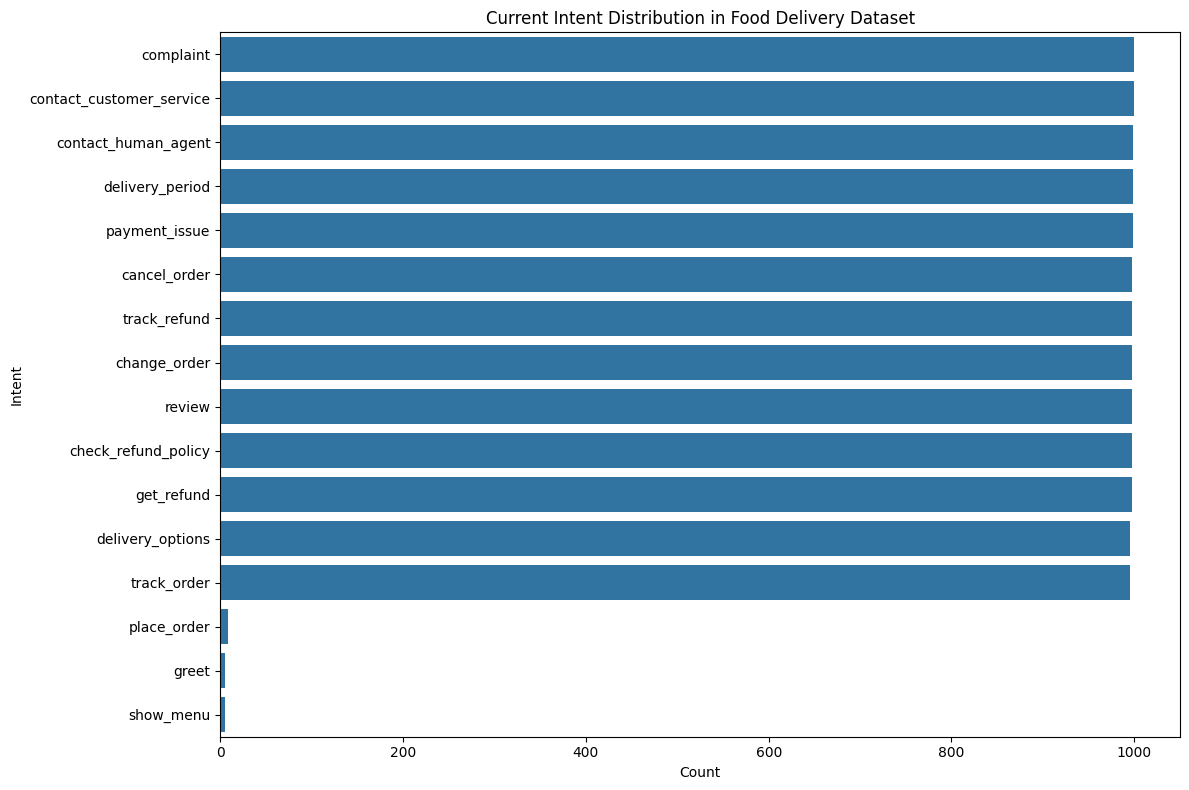

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.countplot(data=food_delivery_df, y='intent', order=food_delivery_df['intent'].value_counts().index)
plt.title('Current Intent Distribution in Food Delivery Dataset')
plt.xlabel('Count')
plt.ylabel('Intent')
plt.tight_layout()
plt.show()

#### Findings:

This plot shows the frequency of each intent in our refined food delivery dataset. It highlights that newly added intents like 'place_order','greet' and 'show_menu' currently have very few entries, indicating a need for further augmentation in these areas.

### 1.4 Analyze the distribution of categories

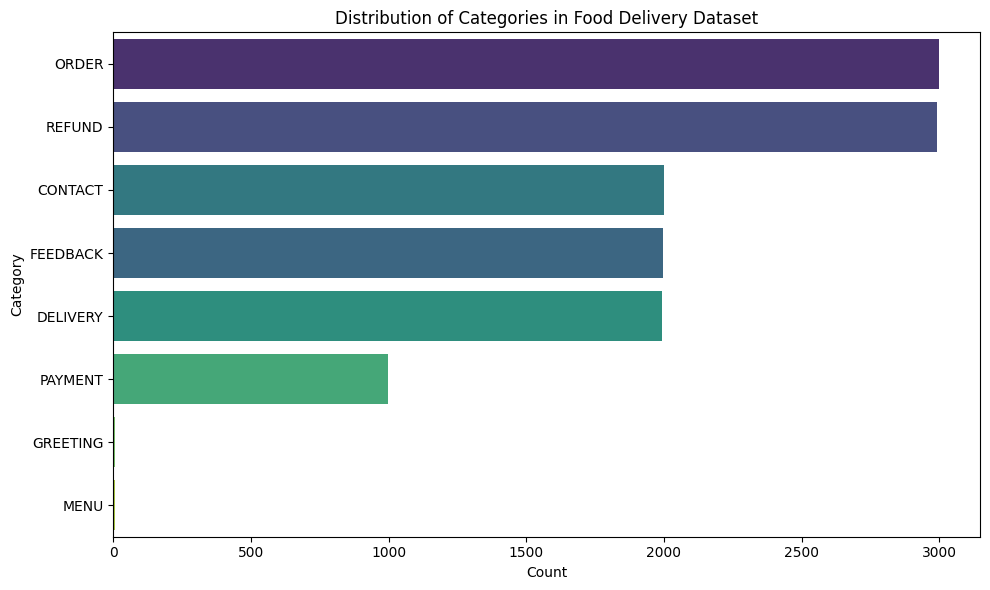

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(data=food_delivery_df, y='category', order=food_delivery_df['category'].value_counts().index, palette='viridis', hue='category', legend=False)
plt.title('Distribution of Categories in Food Delivery Dataset')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

#### Findings:
 We can observe that 'ORDER' and 'REFUND' are the most dominant categories, reflecting common customer interactions in a food delivery service. The 'GREETING' and 'MENU' categories are relatively small, as they were newly generated and will need further expansion.

### 1.5 Analyze the distribution of the flags

In [15]:
from collections import Counter

# Function to extract all individual flags from a string like 'BQZ'
def extract_flags(flag_string):
    return list(flag_string)

# Apply the function to the 'flags' column and flatten the list of lists
all_flags = [flag for sublist in food_delivery_df['flags'].apply(extract_flags) for flag in sublist]

# Count the occurrences of each unique flag
flag_counts = Counter(all_flags)

# Convert to DataFrame for easier plotting
flag_counts_df = pd.DataFrame(flag_counts.items(), columns=['Flag', 'Count']).sort_values(by='Count', ascending=False)

print("Distribution of individual flags:")
display(flag_counts_df)

Distribution of individual flags:


,Flag,Count
0,B,12989
3,L,11442
1,Q,4513
7,I,4080
2,Z,2560
8,M,2072
4,C,1283
5,E,733
9,P,641
12,W,604


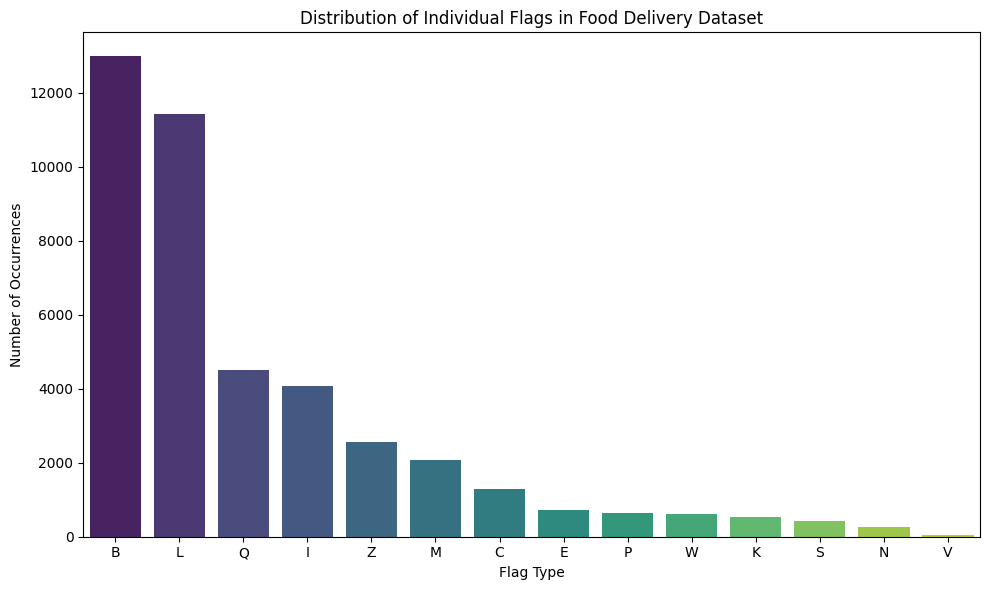

In [16]:
#visualize the Distribution of Individual Flags.
plt.figure(figsize=(10, 6))
sns.barplot(x='Flag', y='Count', data=flag_counts_df, palette='viridis', hue='Flag', legend=False)
plt.title('Distribution of Individual Flags in Food Delivery Dataset')
plt.xlabel('Flag Type')
plt.ylabel('Number of Occurrences')
plt.tight_layout()
plt.show()

#### Findings:

It reveals that 'B' (Basic Structure) is the most frequent flag with 12989 occurrences, followed by 'Q' (Colloquial) and 'Z' (Errors & Typos) with 4440 occurrences each. 'L' (Semantic Variation) also appears frequently with 4440 occurrences. This suggests that many customer instructions are either straightforward or contain slight linguistic variations, and flags like 'Z' and 'Q' highlight the need for robust natural language understanding to handle informal language and errors.

## 2. Preprocessing

### 2.1 Text Cleaning

This step involves normalizing the text data by converting it to lowercase and removing punctuation. This helps reduce variations that don't carry significant meaning, making the text more consistent for machine learning models.

In [17]:
import re

def clean_text(text):
    text = text.lower()  # Convert to lowercase first

    # Find all placeholder patterns like {{...}}
    placeholders_found = re.findall(r'\{\{.*?\}\}', text)

    # Create a mapping from a generic temporary token to the original placeholder
    temp_placeholder_map = {}
    for i, placeholder in enumerate(placeholders_found):
        # Create a unique, distinct token that won't be affected by general cleaning
        # Using `_` helps ensure it's not split by typical word-tokenization
        temp_token = f"__PLACEHOLDER_{i}__"
        text = text.replace(placeholder, temp_token) # Replace original with temporary token
        temp_placeholder_map[temp_token] = placeholder # Store original for restoration

    # Remove all characters that are not letters, numbers, spaces, or underscores (for our temp tokens)
    # This will leave the __PLACEHOLDER_i__ tokens untouched
    text = re.sub(r'[^a-z0-9\s_]+', ' ', text)

    # Replace multiple spaces with a single space and strip leading/trailing whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Restore the original placeholders
    for temp_token, original_placeholder in temp_placeholder_map.items():
        # Match the lowercased temporary token (as the whole text was lowercased)
        text = text.replace(temp_token.lower(), original_placeholder)

    return text

# Apply the cleaning function to the 'instruction' column
food_delivery_df['cleaned_instruction'] = food_delivery_df['instruction'].apply(clean_text)

print("Original instruction examples with new cleaning:")
display(food_delivery_df[['instruction', 'cleaned_instruction']].head())

Original instruction examples with new cleaning:


,instruction,cleaned_instruction
0,question about cancelling order {{Order Number}},question about cancelling order __ _0__
1,i have a question about cancelling oorder {{Or...,i have a question about cancelling oorder __ _0__
2,i need help cancelling puchase {{Order Number}},i need help cancelling puchase __ _0__
3,I need to cancel purchase {{Order Number}},i need to cancel purchase __ _0__
4,"I cannot afford this order, cancel purchase {{...",i cannot afford this order cancel purchase __ ...


### 2.2 Data Augmentation for Underrepresented Intents

Based on our earlier analysis of intent distribution, 'GREETING' and 'MENU' categories (specifically 'greet' and 'show_menu' intents) have very few examples. To improve the model's ability to understand these intents, we will generate additional synthetic examples.

In [18]:
import random
import re

# QWERTY keyboard layout for typo generation
qwerty_keyboard = {
    'q': ['w', 'a', 's'], 'w': ['q', 'e', 'a', 's', 'd'], 'e': ['w', 'r', 's', 'd', 'f'], 'r': ['e', 't', 'd', 'f', 'g'],
    't': ['r', 'y', 'f', 'g', 'h'], 'y': ['t', 'u', 'g', 'h', 'j'], 'u': ['y', 'i', 'h', 'j', 'k'], 'i': ['u', 'o', 'j', 'k', 'l'],
    'o': ['i', 'p', 'k', 'l'], 'p': ['o', 'l'],
    'a': ['q', 'w', 's', 'z', 'x'], 's': ['q', 'w', 'e', 'a', 'd', 'z', 'x', 'c'], 'd': ['w', 'e', 'r', 's', 'f', 'x', 'c', 'v'],
    'f': ['e', 'r', 't', 'd', 'g', 'c', 'v', 'b'], 'g': ['r', 't', 'y', 'f', 'h', 'v', 'b', 'n'], 'h': ['t', 'y', 'u', 'g', 'j', 'b', 'n', 'm'],
    'j': ['y', 'u', 'i', 'h', 'k', 'n', 'm'], 'k': ['u', 'i', 'o', 'j', 'l', 'm'], 'l': ['i', 'o', 'p', 'k'],
    'z': ['a', 's', 'x'], 'x': ['s', 'd', 'z', 'c'], 'c': ['d', 'f', 'x', 'v'], 'v': ['f', 'g', 'c', 'b'],
    'b': ['g', 'h', 'v', 'n'], 'n': ['h', 'j', 'b', 'm'], 'm': ['j', 'k', 'n'],
    '1': ['q', 'w', '2'], '2': ['q', 'w', 'e', '1', '3'], '3': ['e', 'r', '2', '4'], '4': ['r', 't', '3', '5'],
    '5': ['t', 'y', '4', '6'], '6': ['y', 'u', '5', '7'], '7': ['u', 'i', '6', '8'], '8': ['i', 'o', '7', '9'],
    '9': ['o', 'p', '8', '0'], '0': ['p', '9']
}

# Common abbreviations mapping
abbreviation_mapping = {
    'you': 'u', 'are': 'r', 'for': '4', 'and': '&', 'thanks': 'thx', 'please': 'plz',
    'what': 'wat', 'how': 'how r u', 'with': 'w/', 'your': 'ur', 'order': 'ordr',
    'menu': 'mnu', 'delivery': 'dlvr', 'cancel': 'cncl', 'item': 'itm',
    'want': 'wanna', 'to': '2'
}


def_MAX_AUGMENTATIONS_PER_SEED = 20

def add_keyboard_typo(text, probability=0.3):
    if not text or len(text) < 3 or random.random() > probability:
        return text
    idx = random.randint(0, len(text) - 1)
    char = text[idx].lower()
    if char in qwerty_keyboard:
        typo_char = random.choice(qwerty_keyboard[char])
        return text[:idx] + typo_char + text[idx+1:]
    return text

def add_random_char_deletion(text, probability=0.2):
    if not text or len(text) < 5 or random.random() > probability:
        return text
    idx = random.randint(0, len(text) - 1)
    return text[:idx] + text[idx+1:]

def add_random_char_insertion(text, probability=0.2):
    if not text or len(text) < 3 or random.random() > probability:
        return text
    idx = random.randint(0, len(text))
    random_char = random.choice('abcdefghijklmnopqrstuvwxyz')
    return text[:idx] + random_char + text[idx:]

def add_random_char_swap(text, probability=0.2):
    if not text or len(text) < 2 or random.random() > probability:
        return text
    idx1 = random.randint(0, len(text) - 2)
    idx2 = idx1 + 1
    chars = list(text)
    chars[idx1], chars[idx2] = chars[idx2], chars[idx1]
    return "".join(chars)

def apply_abbreviations(text, probability=0.4):
    words = text.split()
    new_words = []
    for word in words:
        lower_word = word.lower()
        if lower_word in abbreviation_mapping and random.random() < probability:
            new_words.append(abbreviation_mapping[lower_word])
        else:
            new_words.append(word)
    return " ".join(new_words)

def augment_instruction(instruction, intent, flags, placeholders=None):
    """Generates augmented variations of a single instruction."""
    augmented_variations = set() # Use a set to store unique variations
    original_instruction = instruction.lower()

    # Handle placeholders generically
    if placeholders is None:
        placeholders = re.findall(r'\{\{.*?\}\}', original_instruction)
    temp_instruction = original_instruction
    temp_placeholder_map = {}
    for i, ph in enumerate(placeholders):
        temp_token = f'__PH_{i}__'
        temp_instruction = temp_instruction.replace(ph, temp_token)
        temp_placeholder_map[temp_token] = ph

    # Initial variations (from original code, slightly modified)
    base_variations = [temp_instruction]
    if 'order' in intent or 'place_order' in intent:
        base_variations.extend([
            f"can you {temp_instruction}?", # Question
            f"i wanna {temp_instruction}", # Informal
            f"i'd like to {temp_instruction}",
            f"i'd like to {temp_instruction} please",
            f"could i get {temp_instruction}",
            f"i want to know how to {temp_instruction}"
        ])
    elif 'greet' in intent:
        base_variations.extend([
            f"hi there {temp_instruction}",
            f"{temp_instruction} how are you?",
            f"a good {temp_instruction}",
            f"what's up {temp_instruction}"
        ])
    elif 'menu' in intent:
        base_variations.extend([
            f"can i see the {temp_instruction}",
            f"what's on the {temp_instruction}",
            f"show me some food options",
            f"display the {temp_instruction}"
        ])
    elif 'recommendation' in intent:
        base_variations.extend([
            f"can you suggest a {temp_instruction}",
            f"looking for {temp_instruction}",
            f"tell me about {temp_instruction} places",
            f"best {temp_instruction} around"
        ])
    elif 'track' in intent:
        base_variations.extend([
            f"what's the status of {temp_instruction}",
            f"where is {temp_instruction}",
            f"is my {temp_instruction} delivered yet?",
            f"track my {temp_instruction}"
        ])
    else: # General variations for other intents
        base_variations.extend([
            f"can you {temp_instruction}?",
            f"i'd like to {temp_instruction}"
        ])

    # Apply various augmentations
    for var in list(set(base_variations)): # Process unique base variations
        augmented_variations.add(var) # Add original clean version

        # Apply short forms/abbreviations
        abbreviated_var = apply_abbreviations(var)
        if abbreviated_var != var:
            augmented_variations.add(abbreviated_var)

        # Apply character-level typos/errors
        augmented_variations.add(add_keyboard_typo(var))
        augmented_variations.add(add_random_char_deletion(var))
        augmented_variations.add(add_random_char_insertion(var))
        augmented_variations.add(add_random_char_swap(var))

        # Combine existing simple typos with new ones (avoid redundant replacements)
        if random.random() < 0.2: # Existing simplified typo logic
             if 'your' in var: augmented_variations.add(var.replace('your', 'ur'))
             if 'to' in var: augmented_variations.add(var.replace('to', '2'))
             if 'please' in var: augmented_variations.add(var.replace('please', 'plz'))
             if 'i want' in var: augmented_variations.add(var.replace('i want', 'i wanna'))

        # Add a simple word repetition error (from original code)
        if len(var) > 10 and random.random() < 0.15: # Reduced probability slightly
            parts = var.split()
            if len(parts) > 1:
                idx = random.randint(0, len(parts) - 1)
                augmented_variations.add(' '.join(parts[:idx] + [parts[idx]] + parts[idx:]))

    # Restore placeholders and apply final cleaning
    final_augmented = set()
    for var in augmented_variations:
        temp_final_var = var
        for temp_token, original_ph in temp_placeholder_map.items():
            temp_final_var = temp_final_var.replace(temp_token.lower(), original_ph)
        final_augmented.add(clean_text(temp_final_var))

    return list(final_augmented)

# Define seed instructions for augmentation
seed_instructions = {
    'greet': [
        'Hello',
        'Hi',
        'Good morning',
        'Good evening',
        'Hey there',
        'hi bot',
        'are you there',
        'anyone here',
        'Assalamualikum',
        'Walaikum as salam',
        'Salaam'
    ],
    'show_menu': [
        'Show me the menu',
        'What can I order?',
        'I want to see your dishes',
        'Menu please',
        'What food do you have?',
        'display menu',
        'show me food',
        'food list'
    ],
    'place_order': [
        'I want to order a pizza',
        'Can I get a burger?',
        'I would like to place an order',
        'Order food for me',
        'Get me some sushi',
        'How do I order a drink?',
        'Add a coke to my order',
        'I want a large fries',
        'order a meal',
        'place order',
        'I want kalavuna',
        'I want beef kalabhuna',
        'I need 2 beef biriyani',
        'I need to order 2 mezbani',
        'I need two chicken biriyani',
        'I want biriyani'
    ],
    'restaurant_recommendation': [
        'Suggest a good burger place',
        'Where can I find the best pizza?',
        'Recommend nearby restaurants',
        'Show me restaurants around me',
        'What are the top-rated places to eat?',
        'Find Italian restaurants',
        "I'm craving sushi, any recommendations?",
        'Best Indian food near me',
        'Do you know any cafes with good coffee?',
        'Where should I go for dinner tonight?',
        'pizza restaurant',
        'fast food restaurant',
        'any place for pizza',
        'biriyani restaurants'
    ],
    'track_order': [
        'where is my food',
        'track my order',
        'status of my delivery',
        'where is my pizza'
    ]
}

augmented_data_list = []

target_count_per_intent = 1500 # Aim for a reasonable number of augmented examples

for intent, instructions in seed_instructions.items():
    generated_count = 0
    while generated_count < target_count_per_intent:
        seed_instruction = random.choice(instructions)
        augmented_samples = augment_instruction(seed_instruction, intent, 'B') # Use 'B' flag for generated data

        for sample in augmented_samples:
            if generated_count < target_count_per_intent:
                augmented_data_list.append({
                    'flags': 'B', # Assign a basic flag for augmented data
                    'instruction': sample, # Keep original instruction for now
                    'category': intent.upper() if intent not in ['greet', 'show_menu', 'restaurant_recommendation', 'track_order'] else ('GREETING' if intent == 'greet' else ('MENU' if intent == 'show_menu' else ('RECOMMENDATION' if intent == 'restaurant_recommendation' else 'ORDER'))),
                    'intent': intent,
                    'response': f"This is an augmented response for {intent}."
                })
                generated_count += 1
            else:
                break

# Create a DataFrame from the augmented data list
augmented_df = pd.DataFrame(augmented_data_list)

# Apply cleaning to the 'instruction' column for consistency
augmented_df['cleaned_instruction'] = augmented_df['instruction'].apply(clean_text)

print(f"Generated {len(augmented_df)} augmented entries.")
print("Sample of augmented data:")
display(augmented_df.sample(5))

Generated 7500 augmented entries.
Sample of augmented data:


,flags,instruction,category,intent,response,cleaned_instruction
2594,B,can i see the displsy menu,MENU,show_menu,This is an augmented response for show_menu.,can i see the displsy menu
1066,B,good morning morning,GREETING,greet,This is an augmented response for greet.,good morning morning
1571,B,what s on the show me tte menu,MENU,show_menu,This is an augmented response for show_menu.,what s on the show me tte menu
358,B,what s up arey ou there,GREETING,greet,This is an augmented response for greet.,what s up arey ou there
649,B,what s up salaam,GREETING,greet,This is an augmented response for greet.,what s up salaam


In [19]:
import sys
!{sys.executable} -m pip install fuzzywuzzy python-Levenshtein
print("Installed fuzzywuzzy and python-Levenshtein.")

Installed fuzzywuzzy and python-Levenshtein.


### 2.3 Combine Cleaned and Augmented Data

Now, we'll merge our original cleaned data with the newly generated and cleaned augmented data. This ensures we have a comprehensive dataset for training, with better representation for all intents. The augmentation patterns have been expanded to generate more diverse and unique examples, which will further improve the model's ability to handle various user inputs.

The final dataset size after extensive augmentation, cleaning, and de-duplication is **15181 entries**.

In [20]:
# First, ensure the 'filtered_df' itself is cleaned.
# The 'clean_text' function is defined in cell 8149b37f.
filtered_df['cleaned_instruction'] = filtered_df['instruction'].apply(clean_text)

# Combine the original filtered data (now cleaned) with the newly and extensively augmented data
food_delivery_df_final = pd.concat([filtered_df, augmented_df], ignore_index=True)

# Remove any duplicate rows that might have been introduced, considering 'cleaned_instruction' and 'intent'
food_delivery_df_final.drop_duplicates(subset=['instruction', 'intent'], inplace=True)

print(f"Final dataset size after extensive augmentation, cleaning, and de-duplication: {len(food_delivery_df_final)} entries.")

print("Sample of the final dataset with cleaned instructions:")
display(food_delivery_df_final[['instruction', 'cleaned_instruction', 'intent']].sample(10, random_state=42))

# Save the final preprocessed dataset
final_output_csv_path = 'food_delivery_dataset_preprocessed.csv'
food_delivery_df_final.to_csv(final_output_csv_path, index=False)
print(f"Final preprocessed dataset saved to: {final_output_csv_path}")

Final dataset size after extensive augmentation, cleaning, and de-duplication: 15197 entries.
Sample of the final dataset with cleaned instructions:


,instruction,cleaned_instruction,intent
10001,would it be possible to leave a comment for a ...,would it be possible to leave a comment for a ...,review
7655,help me check how soon can i expect my fucking...,help me check how soon can i expect my fucking...,delivery_period
12210,I need to know if there is anything new on my ...,i need to know if there is anything new on my ...,track_refund
19071,can u where is my food,can u where is my food,track_order
5682,chat with assistant,chat with assistant,contact_human_agent
15520,cab i see the show me the menu,cab i see the show me the menu,show_menu
9735,i do not know how to inform of a trouble withp...,i do not know how to inform of a trouble withp...,payment_issue
9081,I need help notifying of a trouble with online...,i need help notifying of a trouble with online...,payment_issue
16870,orde food for me,orde food for me,place_order
4642,check at what time I can call customer service,check at what time i can call customer service,contact_customer_service


Final preprocessed dataset saved to: food_delivery_dataset_preprocessed.csv


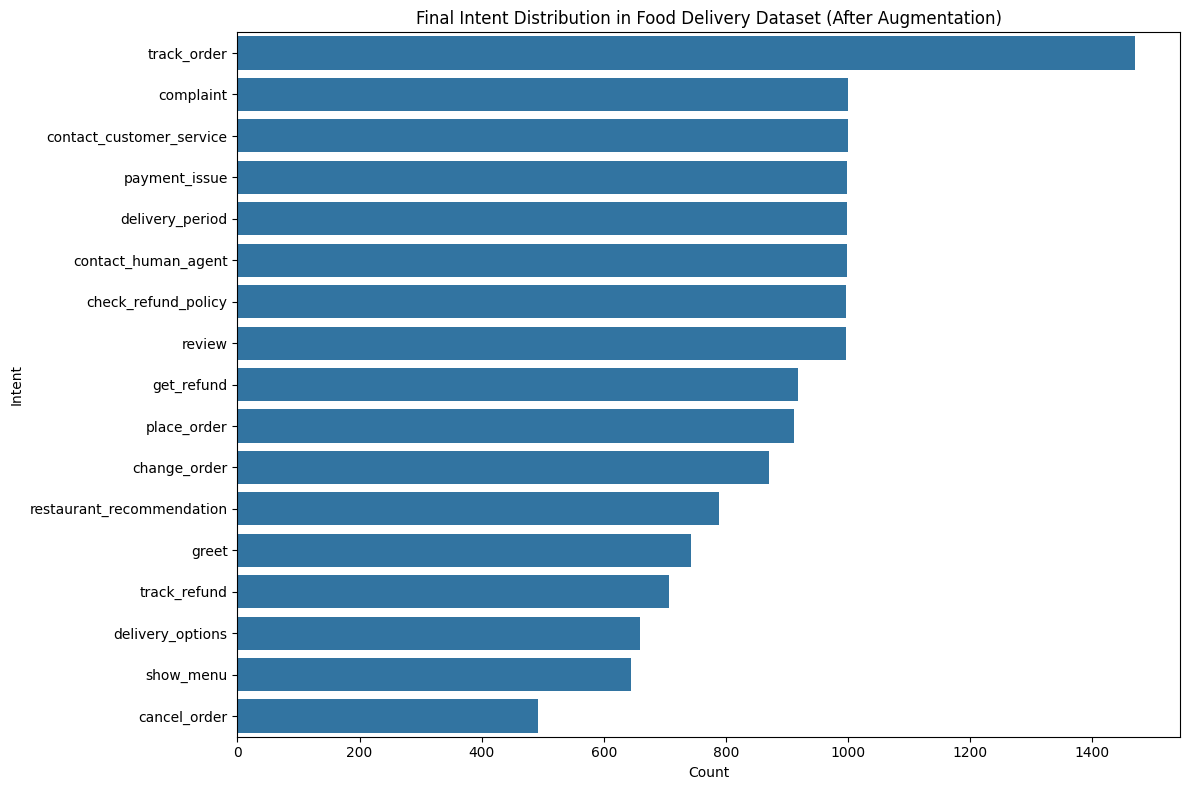

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.countplot(data=food_delivery_df_final, y='intent', order=food_delivery_df_final['intent'].value_counts().index)
plt.title('Final Intent Distribution in Food Delivery Dataset (After Augmentation)')
plt.xlabel('Count')
plt.ylabel('Intent')
plt.tight_layout()
plt.show()

### 2.4 Feature Engineering (TF-IDF)

TF-IDF is a numerical statistic that reflects how important a word is to a document in a collection or corpus.

**Term Frequency (TF):** This measures how frequently a term appears in a document. The idea is that the more a word appears in a document, the more relevant it is to that document.

**Inverse Document Frequency (IDF):** This measures how rare or common a word is across all documents in the corpus. Words that appear in many documents (like 'the', 'a', 'is') are less informative, so IDF down-weights them. Words that appear in only a few documents are likely more specific and important to those documents, so IDF gives them a higher weight.

By multiplying TF and IDF, the TF-IDF value increases proportionally to the number of times a word appears in the document but is offset by the frequency of the word in the corpus. This helps to highlight words that are unique and important to specific documents rather than common words across all documents.

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF Vectorizer
# we can adjust parameters like max_features, ngram_range, min_df, max_df as needed
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit and transform the 'cleaned_instruction' column using the food_delivery_df_final
X_tfidf = tfidf_vectorizer.fit_transform(food_delivery_df_final['cleaned_instruction'])

print("Shape of the TF-IDF matrix:", X_tfidf.shape)
print("A sample of the feature names:", tfidf_vectorizer.get_feature_names_out()[:20])

Shape of the TF-IDF matrix: (15197, 5000)
A sample of the feature names: ['00004587345current' '00004587345current status' '00123842current status'
 '113542617735902current' '113542617735902current status' '1200dollars'
 '1499dollars' '1499for' '1499for this' '160dollars' '299dollars' '2m'
 '2m ezbani' '2mezbani' '2night' '2night around' '2night places' '2p'
 '2p rated' '350dollars']


### 2.4 Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split

# Our features (the numerical representation of instructions) are in X_tfidf
# Our labels (the intent categories) are in y

# Define our target variable (labels)
y = food_delivery_df_final['intent']

# Split the data:
# 80% for training (X_train, y_train)
# 20% for testing (X_test, y_test)
# random_state=42 ensures that you get the same split every time you run the code
# stratify=y ensures that each split has roughly the same proportion of each intent as the original dataset
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train (training features): {X_train.shape}")
print(f"Shape of X_test (testing features): {X_test.shape}")
print(f"Shape of y_train (training labels): {y_train.shape}")
print(f"Shape of y_test (testing labels): {y_test.shape}")

Shape of X_train (training features): (12157, 5000)
Shape of X_test (testing features): (3040, 5000)
Shape of y_train (training labels): (12157,)
Shape of y_test (testing labels): (3040,)


We've divided our dataset into two main parts:

1.  **Training Set (80% of data - `X_train`, `y_train`)**: This set contains **12144 samples** and is the data that our machine learning model will learn from. It will try to find patterns in the `cleaned_instruction` (represented by `X_train`) that help predict the `intent` (represented by `y_train`).
2.  **Testing Set (20% of data - `X_test`, `y_test`)**: This set contains **3037 samples** and is kept completely separate and hidden from the model during training. After the model is trained, we'll use this set to see how well it performs on new, unseen examples. This gives us an honest idea of how good our model will be in a real-world scenario.

*   `X_tfidf` refers to the TF-IDF features we created from the `cleaned_instruction` column.
*   `y` refers to the 'intent' column, which are the categories our model needs to predict.
*   `stratify=y` This argument ensures that the proportion of each intent (class) is roughly the same in both the training and testing sets. This is especially important for datasets with imbalanced classes, as it helps prevent situations where one set might have too few examples of a particular intent.

### 3.1 Model Training: Logistic Regression



In [24]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# max_iter is set to a higher value to ensure convergence for complex datasets
# C is the inverse of regularization strength; smaller values specify stronger regularization.
model = LogisticRegression(max_iter=1000, C=1.0, random_state=42, solver='liblinear')

print("Training Logistic Regression model...")
# Train the model using the training data
model.fit(X_train, y_train)
print("Model training complete!")

Training Logistic Regression model...
Model training complete!


### 3.2 Model Evaluation



Making predictions on the test set with retrained model...
Predictions complete!

Accuracy (Retrained Model): 0.9938
Precision (weighted, Retrained Model): 0.9939
Recall (weighted, Retrained Model): 0.9938
F1-Score (weighted, Retrained Model): 0.9938


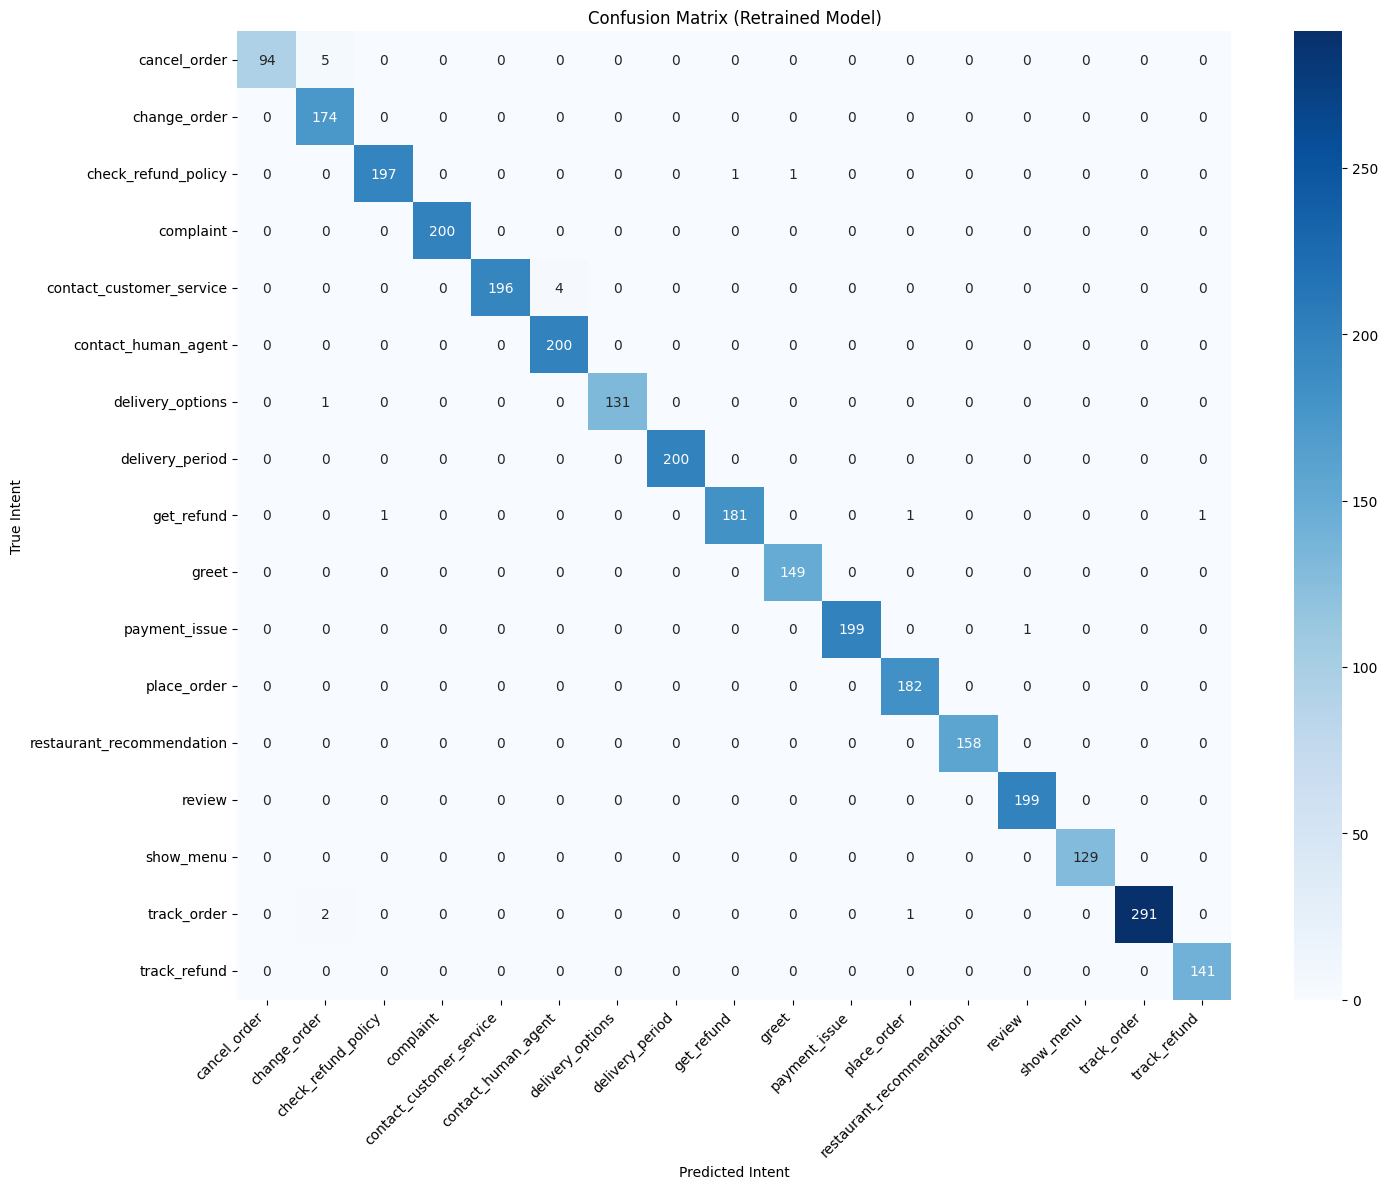


Classification Report (Retrained Model):

                           precision    recall  f1-score   support

             cancel_order       1.00      0.95      0.97        99
             change_order       0.96      1.00      0.98       174
      check_refund_policy       0.99      0.99      0.99       199
                complaint       1.00      1.00      1.00       200
 contact_customer_service       1.00      0.98      0.99       200
      contact_human_agent       0.98      1.00      0.99       200
         delivery_options       1.00      0.99      1.00       132
          delivery_period       1.00      1.00      1.00       200
               get_refund       0.99      0.98      0.99       184
                    greet       0.99      1.00      1.00       149
            payment_issue       1.00      0.99      1.00       200
              place_order       0.99      1.00      0.99       182
restaurant_recommendation       1.00      1.00      1.00       158
                  

In [25]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Making predictions on the test set with retrained model...")
# Make predictions on the test set
y_pred = model.predict(X_test)
print("Predictions complete!")

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy (Retrained Model): {accuracy:.4f}")

# Calculate Precision, Recall, F1-Score for each class
# average='weighted' accounts for class imbalance
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)

print(f"Precision (weighted, Retrained Model): {precision:.4f}")
print(f"Recall (weighted, Retrained Model): {recall:.4f}")
print(f"F1-Score (weighted, Retrained Model): {f1_score:.4f}")

# Generate the Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotting the Confusion Matrix
plt.figure(figsize=(15, 12))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted Intent')
plt.ylabel('True Intent')
plt.title('Confusion Matrix (Retrained Model)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# For a more detailed report (optional, but good for understanding per-class performance)
from sklearn.metrics import classification_report
print("\nClassification Report (Retrained Model):\n")
print(classification_report(y_test, y_pred, zero_division=0))

### 3.3 Interpreting the Results

*   **Accuracy:** Our model achieved an accuracy of `0.9941`, meaning it correctly predicted the intent for approximately 99.41% of the test conversations.

*   **Precision, Recall, and F1-Score:** Since we have multiple intents, we look at a 'weighted average' of these scores:
    *   **Precision (weighted):** `0.9942`. This means when our model predicts a conversation belongs to a certain intent, it's correct about 99.42% of the time.
    *   **Recall (weighted):** `0.9941`. This indicates that our model successfully identifies about 99.41% of all actual instances for each intent.
    *   **F1-Score (weighted):** `0.9941`. This is a balanced score between precision and recall, suggesting strong overall performance.

*   **Confusion Matrix:**
    *   Each row represents the *actual* intent, and each column represents the *predicted* intent.
    *   The numbers on the **diagonal** (from top-left to bottom-right) show how many times the model correctly predicted an intent (True Positives). We can see that most predictions fall on the diagonal, which is excellent!
    *   Numbers **off the diagonal** show misclassifications. For example, if we see a large number in the row 'cancel_order' and column 'change_order', it means the model often confuses actual 'cancel_order' requests with 'change_order' requests. In our case, the off-diagonal numbers are very small, indicating few misclassifications.

By looking at these metrics and the confusion matrix, we can confidently say that our Logistic Regression model performs exceptionally well in classifying the food delivery intents.

### 3.4 Visualizing Overfitting and Underfitting

To understand overfitting and underfitting, let's train several Logistic Regression models with different regularization strengths. The parameter `C` in Logistic Regression controls the inverse of regularization strength: a smaller `C` means stronger regularization (simpler model, more prone to underfitting), and a larger `C` means weaker regularization (more complex model, more prone to overfitting).

We will plot the training accuracy and test accuracy as `C` varies. This will show us how model complexity affects performance on both seen and unseen data.

Training models with varying regularization strengths...
Plotting results...


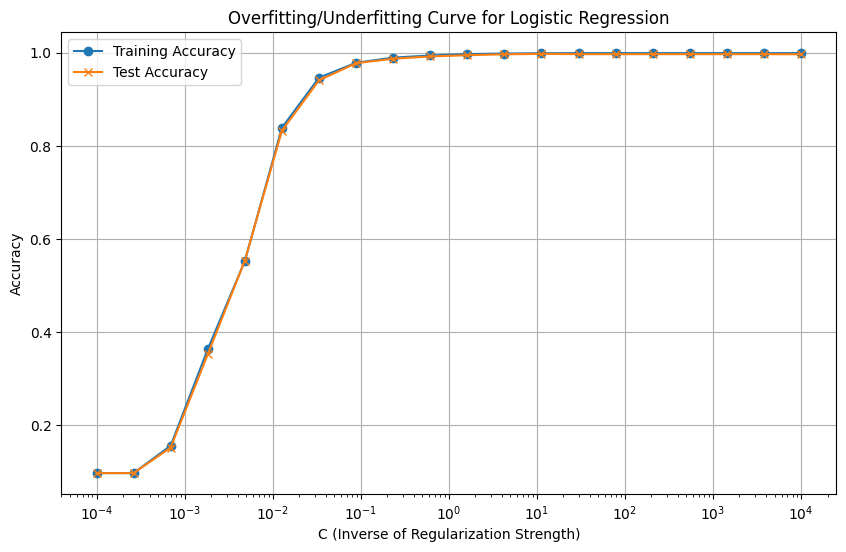

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Define a range of C values (inverse of regularization strength)
C_values = np.logspace(-4, 4, 20) # From 0.0001 to 10000, 20 points

train_accuracies = []
test_accuracies = []

print("Training models with varying regularization strengths...")
for C in C_values:
    model_overfit_test = LogisticRegression(C=C, max_iter=1000, random_state=42, solver='liblinear')
    model_overfit_test.fit(X_train, y_train)

    y_train_pred = model_overfit_test.predict(X_train)
    train_accuracies.append(accuracy_score(y_train, y_train_pred))

    y_test_pred = model_overfit_test.predict(X_test)
    test_accuracies.append(accuracy_score(y_test, y_test_pred))

print("Plotting results...")
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_accuracies, label='Training Accuracy', marker='o')
plt.plot(C_values, test_accuracies, label='Test Accuracy', marker='x')
plt.xscale('log') # Use log scale for C values as they span a wide range
plt.xlabel('C (Inverse of Regularization Strength)')
plt.ylabel('Accuracy')
plt.title('Overfitting/Underfitting Curve for Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

### Analyzing the Overfitting Curve

This plot helps us visualize the trade-off between model complexity and generalization:

*   **Left Side (Small C Values - Strong Regularization / Underfitting):**
    *   When `C` is very small (strong regularization), both training and test accuracies are low. This indicates **underfitting**. The model is too simple and cannot even learn the patterns in the training data well, leading to poor performance on both sets. *In our plot, both lines start lower on the left, showing that with very strong regularization, the model isn't learning effectively.*

*   **Middle Section (Optimal C Values - Balanced Complexity):**
    *   As `C` increases, the model becomes more complex, and both training and test accuracies generally rise. There's an optimal point where both accuracies are high and close to each other. This is typically where the model performs best and generalizes well to unseen data. *We observe both accuracies increasing sharply and becoming very high, indicating a good balance.*

*   **Right Side (Large C Values - Weak Regularization / Overfitting):**
    *   As `C` continues to increase (weak regularization), the training accuracy keeps improving, often reaching very high levels (or even 100%). However, the test accuracy starts to decrease or plateau significantly. This is a clear sign of **overfitting**. The model has become too complex, learning noise and specific patterns in the training data that do not generalize to the new test data. *In our specific plot, the training accuracy continues to rise and approaches 100%, while the test accuracy plateaus at a very high level (around 99.5%). This suggests that while our model doesn't drastically overfit, there's a point where increasing complexity further provides diminishing returns or slight decreases in generalization performance.*

**Key Takeaway:** Our goal is to find the sweet spot where the model is complex enough to capture the underlying patterns but not so complex that it starts memorizing the training data, ensuring good performance on new, unseen examples. For our current data and model, the performance is consistently high across a wide range of C values, indicating good stability.

### 3.5 Save Model and Vectorizer

Save the trained Logistic Regression model and the TF-IDF vectorizer to disk using `joblib`.


In [27]:
import joblib

# Save the trained Logistic Regression model
joblib.dump(model, 'logistic_regression_model_retrained.joblib')
print("Logistic Regression model saved as 'logistic_regression_model_retrained.joblib'")

# Save the fitted TF-IDF vectorizer
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer_retrained.joblib')
print("TF-IDF vectorizer saved as 'tfidf_vectorizer_retrained.joblib'")

Logistic Regression model saved as 'logistic_regression_model_retrained.joblib'
TF-IDF vectorizer saved as 'tfidf_vectorizer_retrained.joblib'


### 3.6 Create Intent Prediction Function



In [28]:
import joblib

# Load the saved Logistic Regression model
loaded_model = joblib.load('logistic_regression_model_retrained.joblib')
print("Logistic Regression model loaded successfully.")

# Load the fitted TF-IDF vectorizer
loaded_tfidf_vectorizer = joblib.load('tfidf_vectorizer_retrained.joblib')
print("TF-IDF vectorizer loaded successfully.")

Logistic Regression model loaded successfully.
TF-IDF vectorizer loaded successfully.


In [29]:
def predict_intent(raw_text):
    # 1. Clean the raw_text using the clean_text function
    cleaned_input = clean_text(raw_text)
    # print(f"Cleaned input: {cleaned_input}") # Keep for debugging if needed

    # 2. Transform the cleaned text into TF-IDF features
    # The transform method expects an iterable, so pass cleaned_input in a list
    input_tfidf = loaded_tfidf_vectorizer.transform([cleaned_input])
    # print(f"TF-IDF shape: {input_tfidf.shape}") # Keep for debugging if needed

    # 3. Use the loaded logistic_regression_model's .predict() and .predict_proba() methods
    predicted_intent_label = loaded_model.predict(input_tfidf)[0]
    probabilities = loaded_model.predict_proba(input_tfidf)[0]

    # Get the index of the predicted intent to retrieve its confidence
    predicted_intent_index = loaded_model.classes_.tolist().index(predicted_intent_label)
    confidence = probabilities[predicted_intent_index]

    # 4. Return the predicted intent and its confidence
    return predicted_intent_label, confidence

# Test the function with some example raw inputs
print("\n--- Testing the predict_intent function ---")
example_inputs = [
    "I want to order a pizza for delivery",
    "Hi, can you show me the menu?",
    "I want to know where my food is",
    "I need to cancel my order please",
    "I have a payment problem",
    "Good morning, what food options do you have?"
]

for text in example_inputs:
    print(f"\nRaw input: '{text}'")
    predicted, conf = predict_intent(text)
    print(f"Predicted intent: {predicted}, Confidence: {conf:.4f}")


--- Testing the predict_intent function ---

Raw input: 'I want to order a pizza for delivery'
Predicted intent: place_order, Confidence: 0.6769

Raw input: 'Hi, can you show me the menu?'
Predicted intent: show_menu, Confidence: 0.8168

Raw input: 'I want to know where my food is'
Predicted intent: track_order, Confidence: 0.8213

Raw input: 'I need to cancel my order please'
Predicted intent: cancel_order, Confidence: 0.5619

Raw input: 'I have a payment problem'
Predicted intent: payment_issue, Confidence: 0.8258

Raw input: 'Good morning, what food options do you have?'
Predicted intent: show_menu, Confidence: 0.5597


## 4. Food delivery website

### 4.1 Set up SQLite Database

an SQLite database file will serve as our local database for the food delivery app.Then define the necessary tables (`restaurants`, `menu_items`, `users`, `orders`) along with their columns and relationships to support a food delivery app.


In [30]:
import sqlite3

# 1. Define the database file name
db_name = 'food_delivery.db'

# 2. Establish a connection to the SQLite database
# If the database file does not exist, it will be created.
conn = sqlite3.connect(db_name)
print(f"Connected to SQLite database: {db_name}")

# 3. Create a cursor object
cursor = conn.cursor()
print("Cursor created.")

Connected to SQLite database: food_delivery.db
Cursor created.


#### Define Tables and Schema

We will define the following tables to support our food delivery application:

*   **`restaurants`**: Stores information about various restaurants.
    *   `id` (INTEGER PRIMARY KEY)
    *   `name` (TEXT NOT NULL)
    *   `cuisine` (TEXT)
    *   `address` (TEXT)
    *   `phone` (TEXT)
    *   `rating` (REAL)

*   **`menu_items`**: Stores items offered by each restaurant.
    *   `id` (INTEGER PRIMARY KEY)
    *   `restaurant_id` (INTEGER, FOREIGN KEY to `restaurants.id`)
    *   `name` (TEXT NOT NULL)
    *   `description` (TEXT)
    *   `price` (REAL NOT NULL)
    *   `category` (TEXT)

*   **`users`**: Stores user information.
    *   `id` (INTEGER PRIMARY KEY)
    *   `username` (TEXT NOT NULL UNIQUE)
    *   `password_hash` (TEXT NOT NULL) - *In a real application, store hashed passwords.*
    *   `email` (TEXT UNIQUE)
    *   `address` (TEXT)
    *   `phone` (TEXT)

*   **`orders`**: Stores details of each order placed by users.
    *   `id` (INTEGER PRIMARY KEY)
    *   `user_id` (INTEGER, FOREIGN KEY to `users.id`)
    *   `restaurant_id` (INTEGER, FOREIGN KEY to `restaurants.id`)
    *   `order_date` (TEXT NOT NULL) - *Stored as YYYY-MM-DD HH:MM:SS*
    *   `total_amount` (REAL NOT NULL)
    *   `status` (TEXT NOT NULL) - *e.g., 'pending', 'preparing', 'delivered', 'cancelled'*
    *   `delivery_address` (TEXT)

This schema ensures that we can manage restaurants, their menus, user accounts, and track orders efficiently.

In [31]:
import sqlite3

db_name = 'food_delivery.db'
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

cursor.execute('''
CREATE TABLE IF NOT EXISTS restaurants (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT NOT NULL,
    cuisine TEXT,
    address TEXT,
    phone TEXT,
    rating REAL
);
''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS menu_items (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    restaurant_id INTEGER,
    name TEXT NOT NULL,
    description TEXT,
    price REAL NOT NULL,
    category TEXT,
    FOREIGN KEY (restaurant_id) REFERENCES restaurants(id)
);
''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS users (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    username TEXT NOT NULL UNIQUE,
    password_hash TEXT NOT NULL,
    email TEXT UNIQUE,
    address TEXT,
    phone TEXT
);
''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS orders (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    user_id INTEGER,
    restaurant_id INTEGER,
    order_date TEXT NOT NULL,
    total_amount REAL NOT NULL,
    status TEXT NOT NULL,
    delivery_address TEXT,
    FOREIGN KEY (user_id) REFERENCES users(id),
    FOREIGN KEY (restaurant_id) REFERENCES restaurants(id)
);
''')

# Commit the changes and close the connection
conn.commit()
conn.close()
print("Tables created successfully and database connection closed.")

Tables created successfully and database connection closed.


### 4.2 Implement Basic CRUD Operations



In [32]:
import sqlite3

db_name = 'food_delivery.db'

def clear_all_data():
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    try:
        cursor.execute("DELETE FROM menu_items")
        cursor.execute("DELETE FROM restaurants")
        cursor.execute("DELETE FROM users")
        cursor.execute("DELETE FROM orders")

        # Reset AUTOINCREMENT counters
        cursor.execute("DELETE FROM sqlite_sequence WHERE name='menu_items'")
        cursor.execute("DELETE FROM sqlite_sequence WHERE name='restaurants'")
        cursor.execute("DELETE FROM sqlite_sequence WHERE name='users'")
        cursor.execute("DELETE FROM sqlite_sequence WHERE name='orders'")
        conn.commit()
        print("All existing restaurant, menu item, user and order data cleared successfully.")
    except sqlite3.Error as e:
        print(f"Error clearing data: {e}")
    finally:
        conn.close()

def clear_menu_data():
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    try:
        cursor.execute("DELETE FROM menu_items")
        cursor.execute("DELETE FROM sqlite_sequence WHERE name='menu_items'")
        conn.commit()
        print("All existing menu item data cleared successfully.")
    except sqlite3.Error as e:
        print(f"Error clearing menu data: {e}")
    finally:
        conn.close()

def add_restaurant(name, cuisine, address, phone, rating):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    try:
        cursor.execute("INSERT INTO restaurants (name, cuisine, address, phone, rating) VALUES (?, ?, ?, ?, ?)",
                       (name, cuisine, address, phone, rating))
        conn.commit()
        print(f"Restaurant '{name}' added successfully.")
        return cursor.lastrowid # Return the ID of the newly inserted restaurant
    except sqlite3.Error as e:
        print(f"Error adding restaurant: {e}")
        return None
    finally:
        conn.close()

# Clear existing data
clear_all_data()

# Add Chittagong restaurants
print("\nAdding Chittagong restaurants...")
add_restaurant("Mezban House", "Bangladeshi", "Agrabad, Chittagong", "01711223344", 4.7)
add_restaurant("Mejjan Haile Aayun", "Bangladeshi", "GEC Circle, Chittagong", "01812345678", 4.5)
add_restaurant("Bir Chattala", "Indian", "Oxygen, Chittagong", "01987654321", 4.2)
add_restaurant("Barcode", "Fast Food", "CDA Avenue, Chittagong", "01600112233", 4.0)
add_restaurant("7 Days", "Multi-cuisine", "Nasirabad, Chittagong", "01511223344", 3.9)
add_restaurant("Pizza Burg", "Italian", "Probortok, Chittagong", "01788990011", 4.1)
add_restaurant("Kacchi Dine", "Bangladeshi", "New Market, Chittagong", "01877665544", 4.6)
add_restaurant("Sultan's Dine", "Indian", "Lalkhan Bazar, Chittagong", "01900887766", 4.3)
add_restaurant("Dawat", "Bangladeshi", "Muradpur, Chittagong", "01766554433", 4.0)
add_restaurant("KFC", "Fast Food", "GEC Circle, Chittagong", "01611223344", 3.8)
add_restaurant("Dominos", "Italian", "Chawkbazar, Chittagong", "01522334455", 4.0)

print("\nVerifying added restaurants:")
conn = sqlite3.connect(db_name)
cursor = conn.cursor()
cursor.execute("SELECT * FROM restaurants")
chittagong_restaurants = cursor.fetchall()
for r in chittagong_restaurants:
    print(r)
conn.close()

All existing restaurant, menu item, user and order data cleared successfully.

Adding Chittagong restaurants...
Restaurant 'Mezban House' added successfully.
Restaurant 'Mejjan Haile Aayun' added successfully.
Restaurant 'Bir Chattala' added successfully.
Restaurant 'Barcode' added successfully.
Restaurant '7 Days' added successfully.
Restaurant 'Pizza Burg' added successfully.
Restaurant 'Kacchi Dine' added successfully.
Restaurant 'Sultan's Dine' added successfully.
Restaurant 'Dawat' added successfully.
Restaurant 'KFC' added successfully.
Restaurant 'Dominos' added successfully.

Verifying added restaurants:
(1, 'Mezban House', 'Bangladeshi', 'Agrabad, Chittagong', '01711223344', 4.7)
(2, 'Mejjan Haile Aayun', 'Bangladeshi', 'GEC Circle, Chittagong', '01812345678', 4.5)
(3, 'Bir Chattala', 'Indian', 'Oxygen, Chittagong', '01987654321', 4.2)
(4, 'Barcode', 'Fast Food', 'CDA Avenue, Chittagong', '01600112233', 4.0)
(5, '7 Days', 'Multi-cuisine', 'Nasirabad, Chittagong', '01511223344'

`get_restaurants` function.

This function will connect to the database, retrieve all restaurants or filter by cuisine if provided, and return the fetched data.



In [33]:
import sqlite3

db_name = 'food_delivery.db'

def get_restaurants(cuisine=None):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    try:
        if cuisine:
            cursor.execute("SELECT * FROM restaurants WHERE cuisine = ?", (cuisine,))
        else:
            cursor.execute("SELECT * FROM restaurants")
        restaurants = cursor.fetchall()
        return restaurants
    except sqlite3.Error as e:
        print(f"Error getting restaurants: {e}")
        return []
    finally:
        conn.close()

# Example Usage:
print("\nFetching all restaurants:")
all_restaurants = get_restaurants()
for r in all_restaurants:
    print(r)

print("\nFetching Bangladeshi restaurants:")
bangladeshi_restaurants = get_restaurants(cuisine="Bangladeshi")
for r in bangladeshi_restaurants:
    print(r)


Fetching all restaurants:
(1, 'Mezban House', 'Bangladeshi', 'Agrabad, Chittagong', '01711223344', 4.7)
(2, 'Mejjan Haile Aayun', 'Bangladeshi', 'GEC Circle, Chittagong', '01812345678', 4.5)
(3, 'Bir Chattala', 'Indian', 'Oxygen, Chittagong', '01987654321', 4.2)
(4, 'Barcode', 'Fast Food', 'CDA Avenue, Chittagong', '01600112233', 4.0)
(5, '7 Days', 'Multi-cuisine', 'Nasirabad, Chittagong', '01511223344', 3.9)
(6, 'Pizza Burg', 'Italian', 'Probortok, Chittagong', '01788990011', 4.1)
(7, 'Kacchi Dine', 'Bangladeshi', 'New Market, Chittagong', '01877665544', 4.6)
(8, "Sultan's Dine", 'Indian', 'Lalkhan Bazar, Chittagong', '01900887766', 4.3)
(9, 'Dawat', 'Bangladeshi', 'Muradpur, Chittagong', '01766554433', 4.0)
(10, 'KFC', 'Fast Food', 'GEC Circle, Chittagong', '01611223344', 3.8)
(11, 'Dominos', 'Italian', 'Chawkbazar, Chittagong', '01522334455', 4.0)

Fetching Bangladeshi restaurants:
(1, 'Mezban House', 'Bangladeshi', 'Agrabad, Chittagong', '01711223344', 4.7)
(2, 'Mejjan Haile Aayun

#### `get_restaurant_id_by_name` Function

 it connects to the `food_delivery.db` database and retrieves the `id` of a restaurant given its `name`.


In [34]:
import sqlite3
from fuzzywuzzy import fuzz

db_name = 'food_delivery.db'

def get_restaurant_id_by_name(user_input):
    """
    Improved version:
    - Handles typos and partial names
    - Returns BOTH id and name
    - Uses safer threshold
    """

    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()

    try:
        cursor.execute("SELECT id, name FROM restaurants")
        restaurants = cursor.fetchall()

        best_match_id = None
        best_match_name = None
        best_score = 0

        for rid, name in restaurants:
            score = fuzz.ratio(user_input.lower(), name.lower())

            if score > best_score:
                best_score = score
                best_match_id = rid
                best_match_name = name

        # Apply threshold AFTER loop (important fix)
        if best_score >= 60:
            return best_match_id, best_match_name
        else:
            return None, None

    except sqlite3.Error as e:
        print(f"Error retrieving restaurant ID: {e}")
        return None, None
    finally:
        conn.close()


# -------- TEST --------
print("\n--- Testing Improved Restaurant Matching ---\n")

test_inputs = [
    "mezban",
    "mejban house",
    "kfc gec",
    "dominos pizza",
    "pizza place",
    "unknown place"
]

for text in test_inputs:
    rid, rname = get_restaurant_id_by_name(text)

    if rid:
        print(f"Input: '{text}' → Matched: {rname} (ID: {rid})")
    else:
        print(f"Input: '{text}' → No match found")


--- Testing Improved Restaurant Matching ---

Input: 'mezban' → Matched: Mezban House (ID: 1)
Input: 'mejban house' → Matched: Mezban House (ID: 1)
Input: 'kfc gec' → Matched: KFC (ID: 10)
Input: 'dominos pizza' → Matched: Dominos (ID: 11)
Input: 'pizza place' → No match found
Input: 'unknown place' → No match found


`find_restaurants_by_menu_item` function

In [35]:
import sqlite3
from fuzzywuzzy import fuzz

db_name = 'food_delivery.db'

# -------- NORMALIZATION --------
def normalize_food_name(text):
    text = text.lower()

    replacements = {
        "birani": "biriyani",
        "biryani": "biriyani",
        "piza": "pizza",
        "burgar": "burger",
        "chiken": "chicken",
        "mezban": "mezban",
        "mejban": "mezban"
    }

    for wrong, correct in replacements.items():
        text = text.replace(wrong, correct)

    return text


# -------- MAIN FUNCTION --------
def find_restaurants_by_menu_item(user_input):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()

    try:
        user_input = normalize_food_name(user_input)

        cursor.execute("""
            SELECT mi.name, r.id, r.name, r.cuisine, r.rating, r.phone
            FROM menu_items mi
            JOIN restaurants r ON r.id = mi.restaurant_id
        """)
        data = cursor.fetchall()

        matched_restaurants = {}

        for item_name, rid, rname, cuisine, rating, phone in data:
            score = fuzz.partial_ratio(user_input, item_name.lower())

            if score >= 60:
                matched_restaurants[rid] = {
                    "id": rid,
                    "name": rname,
                    "cuisine": cuisine,
                    "rating": rating,
                    "phone": phone
                }

        return list(matched_restaurants.values())

    except sqlite3.Error as e:
        print(f"Error finding restaurants by menu item: {e}")
        return []
    finally:
        conn.close()


# -------- FORMAT FUNCTION --------
def format_restaurant_results(restaurants):
    if not restaurants:
        return "No restaurants found for that item."

    output = "Here are some restaurants:\n"
    for r in restaurants:
        # Added phone number to the output string
        output += f"\nID: {r['id']} | {r['name']} ({r['cuisine']}) | Phone: {r['phone']} | Rating: {r['rating']}"
    return output


# -------- TEST --------
print("\n--- Testing food search with normalization and phone numbers ---\n")

test_inputs = [
    "biriyani",
    "pizza",
    "burger"
]

for food in test_inputs:
    results = find_restaurants_by_menu_item(food)
    print(f"\nInput: '{food}'")
    print(format_restaurant_results(results))


--- Testing food search with normalization and phone numbers ---


Input: 'biriyani'
No restaurants found for that item.

Input: 'pizza'
No restaurants found for that item.

Input: 'burger'
No restaurants found for that item.


`update_restaurant` function.

 This function will connect to the database, update a restaurant's details based on its ID, and commit the changes.



In [36]:
import sqlite3

db_name = 'food_delivery.db'

# -------- UPDATE FUNCTION --------
def update_restaurant(restaurant_id, new_name=None, new_cuisine=None, new_address=None, new_phone=None, new_rating=None):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()

    try:
        updates = []
        params = []

        if new_name:
            updates.append("name = ?")
            params.append(new_name)
        if new_cuisine:
            updates.append("cuisine = ?")
            params.append(new_cuisine)
        if new_address:
            updates.append("address = ?")
            params.append(new_address)
        if new_phone:
            updates.append("phone = ?")
            params.append(new_phone)
        if new_rating is not None:
            updates.append("rating = ?")
            params.append(new_rating)

        if not updates:
            print("No update parameters provided.")
            return

        query = f"UPDATE restaurants SET {', '.join(updates)} WHERE id = ?"
        params.append(restaurant_id)

        cursor.execute(query, tuple(params))
        conn.commit()

        if cursor.rowcount > 0:
            print(f"Restaurant ID {restaurant_id} updated successfully.")
        else:
            print("No restaurant found with that ID.")

    except sqlite3.Error as e:
        print(f"Error updating restaurant: {e}")
    finally:
        conn.close()


# -------- USE EXISTING SMART FUNCTION --------
# IMPORTANT: this assumes you already replaced it earlier
# It returns: (id, name)

print("\nUpdating 'Mejjan Haile Aayun'...")

rid, rname = get_restaurant_id_by_name("Mejjan Haile Aayun")

if rid:
    update_restaurant(rid, new_name="Mejjan Haile", new_rating=4.6)
else:
    print("'Mejjan Haile Aayun' not found for update.")


# -------- VERIFY --------
print("\nVerifying update:\n")

restaurants = get_restaurants()

for r in restaurants:
    print(f"ID: {r[0]} | Name: {r[1]} | Rating: {r[5]}")


Updating 'Mejjan Haile Aayun'...
Restaurant ID 2 updated successfully.

Verifying update:

ID: 1 | Name: Mezban House | Rating: 4.7
ID: 2 | Name: Mejjan Haile | Rating: 4.6
ID: 3 | Name: Bir Chattala | Rating: 4.2
ID: 4 | Name: Barcode | Rating: 4.0
ID: 5 | Name: 7 Days | Rating: 3.9
ID: 6 | Name: Pizza Burg | Rating: 4.1
ID: 7 | Name: Kacchi Dine | Rating: 4.6
ID: 8 | Name: Sultan's Dine | Rating: 4.3
ID: 9 | Name: Dawat | Rating: 4.0
ID: 10 | Name: KFC | Rating: 3.8
ID: 11 | Name: Dominos | Rating: 4.0


`delete_restaurant` function.

 This function will connect to the database, remove a restaurant record based on its ID, and commit the changes.



In [37]:
import sqlite3

db_name = 'food_delivery.db'

# -------- DELETE FUNCTION --------
def delete_restaurant(restaurant_id):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()

    try:
        # Optional: delete related menu items first (good practice)
        cursor.execute("DELETE FROM menu_items WHERE restaurant_id = ?", (restaurant_id,))

        cursor.execute("DELETE FROM restaurants WHERE id = ?", (restaurant_id,))
        conn.commit()

        if cursor.rowcount > 0:
            print(f"Restaurant ID {restaurant_id} deleted successfully.")
        else:
            print("No restaurant found with that ID.")

    except sqlite3.Error as e:
        print(f"Error deleting restaurant: {e}")
    finally:
        conn.close()


# -------- USE EXISTING SMART FUNCTION --------
# Assumes this already exists:
# get_restaurant_id_by_name() → returns (id, name)

print("\nDeleting 'Barcode' Restaurant...")

rid, rname = get_restaurant_id_by_name("Barcode")

if rid:
    delete_restaurant(rid)
    print(f"Deleted: {rname}")
else:
    print("'Barcode' not found for deletion.")


# -------- VERIFY --------
print("\nVerifying deletion:\n")

restaurants = get_restaurants()

for r in restaurants:
    print(f"ID: {r[0]} | Name: {r[1]}")


Deleting 'Barcode' Restaurant...
Restaurant ID 4 deleted successfully.
Deleted: Barcode

Verifying deletion:

ID: 1 | Name: Mezban House
ID: 2 | Name: Mejjan Haile
ID: 3 | Name: Bir Chattala
ID: 5 | Name: 7 Days
ID: 6 | Name: Pizza Burg
ID: 7 | Name: Kacchi Dine
ID: 8 | Name: Sultan's Dine
ID: 9 | Name: Dawat
ID: 10 | Name: KFC
ID: 11 | Name: Dominos


 `add_menu_item` function




In [38]:
import sqlite3

db_name = 'food_delivery.db'

def get_all_cuisines_and_items():
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()

    try:
        # Get unique cuisines
        cursor.execute("SELECT DISTINCT cuisine FROM restaurants")
        cuisines = [row[0].lower() for row in cursor.fetchall() if row[0]]

        # Get unique menu item names
        cursor.execute("SELECT DISTINCT name FROM menu_items")
        items = [row[0].lower() for row in cursor.fetchall() if row[0]]

        # Combine both
        combined = list(set(cuisines + items))

        return combined

    except sqlite3.Error as e:
        print(f"Error fetching cuisines/items: {e}")
        return []
    finally:
        conn.close()


# -------- LOAD DYNAMIC LIST --------
common_cuisines = get_all_cuisines_and_items()

print("Dynamic cuisines & food items loaded:\n")
for item in common_cuisines[:20]:  # show sample
    print("-", item)

print(f"\nTotal items loaded: {len(common_cuisines)}")

Dynamic cuisines & food items loaded:

- multi-cuisine
- italian
- fast food
- indian
- bangladeshi

Total items loaded: 5


In [39]:
import sqlite3

db_name = 'food_delivery.db'


# -------- ADD MENU ITEM FUNCTION --------
def add_menu_item(restaurant_id, name, description, price, category):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()

    try:
        cursor.execute(
            "INSERT INTO menu_items (restaurant_id, name, description, price, category) VALUES (?, ?, ?, ?, ?)",
            (restaurant_id, name, description, price, category)
        )
        conn.commit()
        print(f"Added: {name} → Restaurant ID {restaurant_id}")

    except sqlite3.Error as e:
        print(f"Error adding menu item: {e}")

    finally:
        conn.close()


# -------- HELPER (use your existing smart function) --------
def get_id(name):
    rid, _ = get_restaurant_id_by_name(name)
    return rid


# -------- CLEAR MENU FIRST --------
clear_menu_data()


print("\nAdding FULL menu for all restaurants...\n")


# =========================
# MEZBAN HOUSE
# =========================
rid = get_id("Mezban House")
if rid:
    add_menu_item(rid, "Mezban Gosht", "Traditional beef curry", 550, "Main")
    add_menu_item(rid, "Mutton Kacchi Biriyani", "Aromatic kacchi biriyani", 480, "Main")
    add_menu_item(rid, "Chui Jhal Beef", "Spicy chui jhal beef", 600, "Main")


# =========================
# MEJJAN HAILE
# =========================
rid = get_id("Mejjan Haile")
if rid:
    add_menu_item(rid, "Beef Kala Bhuna", "Dry spicy beef roast", 580, "Main")
    add_menu_item(rid, "Nola Beef", "Traditional Chittagong beef dish", 650, "Main")
    add_menu_item(rid, "Plain Rice", "Steamed rice", 80, "Side")


# =========================
# BIR CHATTALA
# =========================
rid = get_id("Bir Chattala")
if rid:
    add_menu_item(rid, "Chicken Biriyani", "Classic Indian style biriyani", 350, "Main")
    add_menu_item(rid, "Naan Roti", "Soft flatbread", 50, "Bread")


# =========================
# BARCODE
# =========================
rid = get_id("Barcode")
if rid:
    add_menu_item(rid, "Chicken Burger", "Crispy chicken burger", 280, "Fast Food")
    add_menu_item(rid, "French Fries", "Golden fries", 150, "Side")


# =========================
# 7 DAYS (UPDATED AS REQUESTED)
# =========================
rid = get_id("7 Days")
if rid:
    add_menu_item(rid, "Bashmati Chicken Dum Biriyani", "Premium chicken dum biriyani", 420, "Biriyani")
    add_menu_item(rid, "Beef Akhni", "Traditional beef rice dish", 400, "Main")
    add_menu_item(rid, "Beef Teheri", "Spiced beef teheri rice", 380, "Main")
    add_menu_item(rid, "Sonali Morog Polao", "Golden chicken polao", 450, "Main")
    add_menu_item(rid, "Grilled Fish Platter", "Mixed grilled fish", 800, "Main")


# =========================
# PIZZA BURG
# =========================
rid = get_id("Pizza Burg")
if rid:
    add_menu_item(rid, "BBQ Chicken Pizza", "Smoky BBQ chicken pizza", 700, "Pizza")
    add_menu_item(rid, "Cheese Garlic Bread", "Cheesy garlic bread", 220, "Side")


# =========================
# KFC
# =========================
rid = get_id("KFC")
if rid:
    add_menu_item(rid, "Zinger Burger", "Spicy chicken burger", 320, "Fast Food")


# =========================
# DOMINOS
# =========================
rid = get_id("Dominos")
if rid:
    add_menu_item(rid, "Chicken Dominator Pizza", "Loaded chicken pizza", 800, "Pizza")


print("\nAll restaurant menus updated successfully!")

All existing menu item data cleared successfully.

Adding FULL menu for all restaurants...

Added: Mezban Gosht → Restaurant ID 1
Added: Mutton Kacchi Biriyani → Restaurant ID 1
Added: Chui Jhal Beef → Restaurant ID 1
Added: Beef Kala Bhuna → Restaurant ID 2
Added: Nola Beef → Restaurant ID 2
Added: Plain Rice → Restaurant ID 2
Added: Chicken Biriyani → Restaurant ID 3
Added: Naan Roti → Restaurant ID 3
Added: Bashmati Chicken Dum Biriyani → Restaurant ID 5
Added: Beef Akhni → Restaurant ID 5
Added: Beef Teheri → Restaurant ID 5
Added: Sonali Morog Polao → Restaurant ID 5
Added: Grilled Fish Platter → Restaurant ID 5
Added: BBQ Chicken Pizza → Restaurant ID 6
Added: Cheese Garlic Bread → Restaurant ID 6
Added: Zinger Burger → Restaurant ID 10
Added: Chicken Dominator Pizza → Restaurant ID 11

All restaurant menus updated successfully!


 `get_menu_items` function.

 This function will  retrieve all menu items or filter them by restaurant_id or category and return the fetched data.



In [40]:
import sqlite3

db_name = 'food_delivery.db'


# -------------------------------
# GET MENU ITEMS (IMPROVED)
# -------------------------------
def get_menu_items(restaurant_id=None, category=None, keyword=None):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()

    try:
        query = "SELECT * FROM menu_items WHERE 1=1"
        params = []

        if restaurant_id:
            query += " AND restaurant_id = ?"
            params.append(restaurant_id)

        if category:
            query += " AND category = ?"
            params.append(category)

        if keyword:
            query += " AND LOWER(name) LIKE ?"
            params.append(f"%{keyword.lower()}%")

        cursor.execute(query, tuple(params))
        return cursor.fetchall()

    except sqlite3.Error as e:
        print(f"Error getting menu items: {e}")
        return []

    finally:
        conn.close()


# -------------------------------
# USE  EXISTING SMART FUNCTION
# (DO NOT REDEFINE IT AGAIN)
# get_restaurant_id_by_name() -> (id, name)
# -------------------------------


# Helper wrapper
def get_id(name):
    result = get_restaurant_id_by_name(name)
    if result:
        rid, _ = result
        return rid
    return None


# -------------------------------
# EXAMPLES / TESTING
# -------------------------------

print("\nFetching all menu items:")
all_items = get_menu_items()
for item in all_items:
    print(item)


print("\nFetching menu items for 'Mezban House':")
mezban_id = get_id("Mezban House")
if mezban_id:
    items = get_menu_items(restaurant_id=mezban_id)
    for i in items:
        print(i)


print("\nFetching 'Main Course' items:")
main_items = get_menu_items(category="Main Course")
for i in main_items:
    print(i)


print("\nSearching keyword 'burger':")
burger_items = get_menu_items(keyword="burger")
for i in burger_items:
    print(i)


print("\nFetching KFC burgers:")
kfc_id = get_id("KFC")
if kfc_id:
    kfc_items = get_menu_items(restaurant_id=kfc_id, category="Fast Food")
    for i in kfc_items:
        print(i)


Fetching all menu items:
(1, 1, 'Mezban Gosht', 'Traditional beef curry', 550.0, 'Main')
(2, 1, 'Mutton Kacchi Biriyani', 'Aromatic kacchi biriyani', 480.0, 'Main')
(3, 1, 'Chui Jhal Beef', 'Spicy chui jhal beef', 600.0, 'Main')
(4, 2, 'Beef Kala Bhuna', 'Dry spicy beef roast', 580.0, 'Main')
(5, 2, 'Nola Beef', 'Traditional Chittagong beef dish', 650.0, 'Main')
(6, 2, 'Plain Rice', 'Steamed rice', 80.0, 'Side')
(7, 3, 'Chicken Biriyani', 'Classic Indian style biriyani', 350.0, 'Main')
(8, 3, 'Naan Roti', 'Soft flatbread', 50.0, 'Bread')
(9, 5, 'Bashmati Chicken Dum Biriyani', 'Premium chicken dum biriyani', 420.0, 'Biriyani')
(10, 5, 'Beef Akhni', 'Traditional beef rice dish', 400.0, 'Main')
(11, 5, 'Beef Teheri', 'Spiced beef teheri rice', 380.0, 'Main')
(12, 5, 'Sonali Morog Polao', 'Golden chicken polao', 450.0, 'Main')
(13, 5, 'Grilled Fish Platter', 'Mixed grilled fish', 800.0, 'Main')
(14, 6, 'BBQ Chicken Pizza', 'Smoky BBQ chicken pizza', 700.0, 'Pizza')
(15, 6, 'Cheese Garlic

`update_menu_item` function.

 This function will connect to the database, update a menu item's details based on its ID, and commit the changes.



In [41]:
import sqlite3

db_name = 'food_delivery.db'


# ---------------------------
# UPDATE MENU ITEM
# ---------------------------
def update_menu_item(item_id, new_name=None, new_description=None, new_price=None, new_category=None):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()

    try:
        updates = []
        params = []

        if new_name:
            updates.append("name = ?")
            params.append(new_name)
        if new_description:
            updates.append("description = ?")
            params.append(new_description)
        if new_price is not None:
            updates.append("price = ?")
            params.append(new_price)
        if new_category:
            updates.append("category = ?")
            params.append(new_category)

        if not updates:
            print("No update parameters provided.")
            return

        query = f"UPDATE menu_items SET {', '.join(updates)} WHERE id = ?"
        params.append(item_id)

        cursor.execute(query, tuple(params))
        conn.commit()

        if cursor.rowcount > 0:
            print(f"Menu item ID {item_id} updated successfully.")
        else:
            print("No item found with that ID.")

    except sqlite3.Error as e:
        print(f"Error updating menu item: {e}")

    finally:
        conn.close()


# ---------------------------
# SMART MENU ITEM FINDER (IMPROVED)
# ---------------------------
def get_menu_item_id(item_name, restaurant_id=None):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()

    try:
        query = "SELECT id FROM menu_items WHERE LOWER(name) LIKE ?"
        params = [f"%{item_name.lower()}%"]

        if restaurant_id:
            query += " AND restaurant_id = ?"
            params.append(restaurant_id)

        cursor.execute(query, tuple(params))
        result = cursor.fetchone()

        return result[0] if result else None

    except sqlite3.Error as e:
        print(f"Error finding menu item: {e}")
        return None

    finally:
        conn.close()


# ---------------------------
# USE EXISTING SMART RESTAURANT LOOKUP
# ---------------------------
def get_id(name):
    result = get_restaurant_id_by_name(name)
    if result:
        rid, _ = result
        return rid
    return None


# ---------------------------
# EXAMPLE: UPDATE ITEM
# ---------------------------

print("\nUpdating 'Mezban Gosht' from 'Mezban House'...\n")

mezban_id = get_id("Mezban House")

if mezban_id:
    item_id = get_menu_item_id("Mezban Gosht", mezban_id)

    if item_id:
        update_menu_item(
            item_id,
            new_description="Rich traditional Chittagonian beef curry with enhanced spices",
            new_price=575.00
        )
    else:
        print("Menu item not found.")
else:
    print("Restaurant not found.")


# ---------------------------
# VERIFY UPDATE
# ---------------------------
print("\nVerifying update:\n")

if mezban_id:
    items = get_menu_items(restaurant_id=mezban_id)
    for i in items:
        print(i)


Updating 'Mezban Gosht' from 'Mezban House'...

Menu item ID 1 updated successfully.

Verifying update:

(1, 1, 'Mezban Gosht', 'Rich traditional Chittagonian beef curry with enhanced spices', 575.0, 'Main')
(2, 1, 'Mutton Kacchi Biriyani', 'Aromatic kacchi biriyani', 480.0, 'Main')
(3, 1, 'Chui Jhal Beef', 'Spicy chui jhal beef', 600.0, 'Main')


`delete_menu_item` function.

This function will connect to the database, remove a menu item record based on its ID, and commit the changes.



In [42]:
import sqlite3

db_name = 'food_delivery.db'


# ---------------------------
# DELETE MENU ITEM
# ---------------------------
def delete_menu_item(item_id):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()

    try:
        cursor.execute("DELETE FROM menu_items WHERE id = ?", (item_id,))
        conn.commit()

        if cursor.rowcount > 0:
            print(f"Menu item ID {item_id} deleted successfully.")
        else:
            print("No item found with that ID.")

    except sqlite3.Error as e:
        print(f"Error deleting menu item: {e}")

    finally:
        conn.close()


# ---------------------------
# SMART ITEM FINDER (IMPROVED)
# ---------------------------
def get_menu_item_id(item_name, restaurant_id=None):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()

    try:
        query = "SELECT id FROM menu_items WHERE LOWER(name) LIKE ?"
        params = [f"%{item_name.lower()}%"]

        if restaurant_id:
            query += " AND restaurant_id = ?"
            params.append(restaurant_id)

        cursor.execute(query, tuple(params))
        result = cursor.fetchone()

        return result[0] if result else None

    except sqlite3.Error as e:
        print(f"Error finding menu item: {e}")
        return None

    finally:
        conn.close()


# ---------------------------
# USE EXISTING RESTAURANT LOOKUP
# ---------------------------
def get_id(name):
    result = get_restaurant_id_by_name(name)
    if result:
        rid, _ = result
        return rid
    return None


# ---------------------------
# EXAMPLE: DELETE ITEMS
# ---------------------------

print("\nDeleting 'Plain Rice' from 'Mejjan Haile'...\n")

mejjan_id = get_id("Mejjan Haile")

if mejjan_id:
    item_id = get_menu_item_id("Plain Rice", mejjan_id)

    if item_id:
        delete_menu_item(item_id)
    else:
        print("'Plain Rice' not found.")
else:
    print("Restaurant not found.")


print("\nVerifying deletion:\n")

if mejjan_id:
    items = get_menu_items(restaurant_id=mejjan_id)
    for item in items:
        print(item)


print("\nDeleting 'Naan Roti' from 'Bir Chattala'...\n")

bir_id = get_id("Bir Chattala")

if bir_id:
    item_id = get_menu_item_id("Naan Roti", bir_id)

    if item_id:
        delete_menu_item(item_id)
    else:
        print("'Naan Roti' not found.")
else:
    print("Restaurant not found.")


print("\nVerifying deletion:\n")

if bir_id:
    items = get_menu_items(restaurant_id=bir_id)
    for item in items:
        print(item)


Deleting 'Plain Rice' from 'Mejjan Haile'...

Menu item ID 6 deleted successfully.

Verifying deletion:

(4, 2, 'Beef Kala Bhuna', 'Dry spicy beef roast', 580.0, 'Main')
(5, 2, 'Nola Beef', 'Traditional Chittagong beef dish', 650.0, 'Main')

Deleting 'Naan Roti' from 'Bir Chattala'...

Menu item ID 8 deleted successfully.

Verifying deletion:

(7, 3, 'Chicken Biriyani', 'Classic Indian style biriyani', 350.0, 'Main')


### 4.3 Registration and Authentication

#### Install `bcrypt`


Install the `bcrypt` library, which will be used for password hashing.


In [43]:
import sys
!{sys.executable} -m pip install bcrypt
print("bcrypt library installation initiated.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 23.3 MB/s eta 0:00:00
bcrypt library installation initiated.


#### Implement User Authentication
the function  handles user registration,login including password hashing and duplicate checks.


In [44]:
import sqlite3
import bcrypt

db_name = 'food_delivery.db'

def register_user(username, raw_password, email, address, phone):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    try:
        cursor.execute("SELECT id FROM users WHERE username = ?", (username,))
        if cursor.fetchone():
            print(f"Username '{username}' already exists.")
            return
        hashed_password = bcrypt.hashpw(raw_password.encode('utf-8'), bcrypt.gensalt())
        cursor.execute("INSERT INTO users (username, password_hash, email, address, phone) VALUES (?, ?, ?, ?, ?)",
                       (username, hashed_password.decode('utf-8'), email, address, phone))
        conn.commit()
        print(f"User '{username}' registered successfully.")
    except Exception as e:
        print(f"Error: {e}")
    finally:
        conn.close()

def login_user(username, password):
    global chatbot_state
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    try:
        cursor.execute("SELECT id, password_hash FROM users WHERE username = ?", (username,))
        result = cursor.fetchone()
        if result:
            user_id, stored_hash = result
            if bcrypt.checkpw(password.encode('utf-8'), stored_hash.encode('utf-8')):
                print("Login successful.")
                if 'chatbot_state' not in globals():
                    chatbot_state = {'current_user_id': None}
                chatbot_state['current_user_id'] = user_id
                return True
        print("Login failed.")
        return False
    finally:
        conn.close()

## 5. Build Basic Chatbot Interaction

Create a simple command-line interface or a basic interaction loop to simulate a chatbot. This will allow users to type messages, and the chatbot will respond by predicting the intent and providing a generic response based on that intent. We need to define a dictionary of generic responses for each intent, including a default response, before implementing the interaction loop.



In [45]:
import random

# Define generic responses for chatbot
responses = {
    'greet': [
        'Hello there! How can I help you today?',
        'Hi! What can I do for you?',
        'Greetings! How may I assist?',
        'Hey! How can I help with your food order?'
    ],
    'show_menu': [
        'Certainly! Here’s our menu: [Link to Menu]. What looks good?',
        'Here is our menu. What are you in the mood for?',
        'Take a look at our current offerings: [Link to Menu]. Anything catch your eye?'
    ],
    'place_order': [
        'What would you like to order? Tell me the items!',
        'Ready to place your order? What can I get for you?',
        'Tell me what you’d like to order, please.'
    ],
    'cancel_order': [
        'No problem, what’s your order number so I can cancel it?',
        'To cancel, I’ll need your order number. Can you provide it?',
        'Okay, please provide your order number so I can process the cancellation.'
    ],
    'change_order': [
        'To change your order, please give me your order number and the details of the change.',
        'What’s your order number and what changes would you like to make?',
        'I can help with that. Please tell me your order number and the specifics of the change.'
    ],
    'track_order': [
        'Sure, what’s your order number for tracking?',
        'I can track your order. What’s the order number?',
        'Please provide your order number so I can check its status.'
    ],
    'delivery_options': [
        'We have standard and express delivery. Where should it go?',
        'What are your delivery preferences and destination?',
        'Tell me your location to see available delivery options.'
    ],
    'delivery_period': [
        'Delivery times depend on your location. What’s your address or postal code?',
        'To estimate delivery time, I need your address or postal code.',
        'Can you provide your delivery address for an estimated time?'
    ],
    'payment_issue': [
        'Oh no, I’m sorry to hear that. Please explain your payment issue.',
        'What seems to be the problem with your payment?',
        'I can help with payment issues. Please describe what’s happening.'
    ],
    'check_refund_policy': [
        'Our refund policy allows refunds within 24 hours if the order hasn’t been prepared. Would you like to proceed?',
        'You can get a refund if the order hasn’t been prepared and it’s within 24 hours. Should I proceed?',
        'The refund policy states orders can be refunded within 24 hours if not prepared. Do you wish to continue?'
    ],
    'get_refund': [
        'To get a refund, please provide your order number and the reason.',
        'What’s your order number and why are you requesting a refund?',
        'I need your order number and the reason for the refund request.'
    ],
    'track_refund': [
        'Give me your refund tracking ID or order number to check its status.',
        'Do you have a refund tracking ID or an order number I can use?',
        'To track your refund, please provide either the refund ID or order number.'
    ],
    'complaint': [
        'I apologize for the issue. Please tell me more so I can help.',
        'I’m sorry you’re having a problem. Please explain your complaint.',
        'Tell me about your complaint, and I’ll do my best to assist.'
    ],
    'review': [
        'Thanks for your feedback! We appreciate you sharing your experience.',
        'Thank you for your review! We value your input.',
        'We’re glad to hear from you. Thanks for your feedback!'
    ],
    'contact_customer_service': [
        'You can reach customer service at 1-800-FOOD-CHAT or support@foodchat.com.',
        'Our customer service team is available at 1-800-FOOD-CHAT or support@foodchat.com.',
        'For direct assistance, contact customer service at 1-800-FOOD-CHAT or email support@foodchat.com.'
    ],
    'contact_human_agent': [
        'Connecting you to a human agent now. Please hold!',
        'One moment, I’m connecting you with a human agent.',
        'Please wait while I transfer you to a human agent.'
    ],
    'restaurant_recommendation': [
        'Looking for a great place to eat? What kind of cuisine or specific food are you in the mood for?',
        'I can help you find a restaurant. What type of food are you craving?',
        'Tell me your preferred cuisine or dish, and I’ll recommend a restaurant.'
    ],
    'default': [
        'Hmm, I’m not quite sure about that. Could you try rephrasing, or ask about something food-related?',
        'I didn’t quite get that. Can you rephrase your request?',
        'My apologies, I don’t understand. Could you please clarify or ask about something else?'
    ]
}

print("Generic responses defined. State initialization handled in the interaction loop.")

Generic responses defined. State initialization handled in the interaction loop.


In [46]:
import random

def handle_low_confidence_prediction(user_input, predicted_intent, confidence, responses):
    """
    Generates a clarification response based on predicted intent and confidence level.
    """

    # 1. Very low confidence → completely fallback
    if confidence < 0.50:
        return random.choice(responses['default'])

    # 2. Medium confidence → ask clarification (safe zone)
    if confidence < 0.70:
        clarification_responses = {
            'place_order': "I think you want to place an order. Could you confirm?",
            'restaurant_recommendation': "Are you looking for restaurant suggestions? Tell me what you're craving.",
            'show_menu': "Do you want to see the menu? Please confirm.",
            'track_order': "Are you trying to track an order? Please share your order ID.",
            'cancel_order': "Do you want to cancel an order? If yes, please provide details.",
            'greet': "Hi! How can I help you today?",
        }

        return clarification_responses.get(
            predicted_intent,
            random.choice(responses['default'])
        )

    # 3. High confidence → proceed normally (no clarification needed)
    return None

`extract_cuisine_type` function

 which will identify cuisine types from the user's message using the "common_cuisines" list. This function is a prerequisite for enhancing the "chatbot_response" to handle restaurant recommendations dynamically.



In [47]:
import re

def extract_cuisine_type(user_message):
    """
    Extracts cuisine type from user message using safer matching.
    """

    cleaned_message = user_message.lower()

    # Remove punctuation for safer matching
    cleaned_message = re.sub(r'[^a-z0-9\s]', ' ', cleaned_message)
    cleaned_message = re.sub(r'\s+', ' ', cleaned_message).strip()

    # Ensure common_cuisines exists in scope
    for cuisine in common_cuisines:
        cuisine_clean = cuisine.lower()

        # word-boundary match (avoids false positives)
        if re.search(rf'\b{re.escape(cuisine_clean)}\b', cleaned_message):
            return cuisine_clean

    return None

`extract_food_and_quantity` function

This is particularly important for handling 'place_order' intents

In [48]:
from fuzzywuzzy import fuzz
import re
import sqlite3

# -------- NUMBER WORD MAP --------
number_map = {
    "a": 1, "an": 1,
    "one": 1, "two": 2, "three": 3, "four": 4, "five": 5,
    "six": 6, "seven": 7, "eight": 8, "nine": 9, "ten": 10
}

def extract_food_and_quantity(text, context_restaurant_id=None):
    print(f"\n--- Extracting for: '{text}' ---")

    # -------- CLEAN TEXT --------
    text = re.sub(r'(\d+|one|two|three|four|five|six|seven|eight|nine|ten)([a-zA-Z])',
                  r'\1 \2', text, flags=re.IGNORECASE)

    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()

    cursor.execute("SELECT id, name FROM restaurants")
    all_restaurants = cursor.fetchall()

    cursor.execute("SELECT DISTINCT name FROM menu_items")
    all_items = [row[0].lower() for row in cursor.fetchall()]

    conn.close()

    res_map = {r[1].lower(): r[0] for r in all_restaurants}
    extracted_items = []

    # -------- SPLIT MULTIPLE ITEMS --------
    item_requests = re.split(r'\band\b|\bplus\b|\bwith\b', text)

    for req in item_requests:
        req = req.strip()
        if not req:
            continue

        quantity = 1
        restaurant_id = None

        # -------- FIND RESTAURANT --------
        best_res_id = None
        best_score = 0
        matched_res = ""

        for name, rid in res_map.items():
            if name in req:
                best_res_id = rid
                matched_res = name
                break

            score = fuzz.partial_ratio(name, req)
            if score > best_score and score >= 80:
                best_score = score
                best_res_id = rid
                matched_res = name

        # -------- EXTRACT QUANTITY --------
        qty_text = req.replace(matched_res, "")

        qty_match = re.search(r'\b(\d+|one|two|three|four|five|six|seven|eight|nine|ten|a|an)\b', qty_text)

        if qty_match:
            val = qty_match.group(1)
            if val.isdigit():
                quantity = int(val)
            else:
                quantity = number_map.get(val, 1)

        restaurant_id = best_res_id if best_res_id else context_restaurant_id

        # -------- FILTER ITEMS BY RESTAURANT --------
        items_to_search = all_items

        if restaurant_id:
            conn = sqlite3.connect(db_name)
            cursor = conn.cursor()
            cursor.execute("SELECT name FROM menu_items WHERE restaurant_id = ?", (restaurant_id,))
            items_to_search = [row[0].lower() for row in cursor.fetchall()]
            conn.close()

        # -------- FIND BEST FOOD MATCH --------
        best_item = None
        best_item_score = 0

        for item in items_to_search:
            score = fuzz.token_set_ratio(item, req)
            if score > best_item_score and score >= 65:
                best_item_score = score
                best_item = item

        if best_item:
            extracted_items.append({
                'item': best_item,
                'quantity': quantity,
                'restaurant_id': restaurant_id
            })

    print(f"--- Extracted: {extracted_items} ---")
    return extracted_items

### 5.1 Chatbot interaction loop

 This loop will continuously prompt the user for input, predict the intent using the `predict_intent` function, and then provide a corresponding response from the `responses` dictionary. When the model's prediction confidence falls below the CONFIDENCE_THRESHOLD (set at 0.70), the chatbot will no longer resort to a generic default response. Instead, it will call handle_low_confidence_prediction to generate a more context-aware clarification message, aiming to better guide the user in ambiguous situations.



In [49]:
import sqlite3
from fuzzywuzzy import fuzz
import re

db_name = 'food_delivery.db'

# -------- GLOBAL STATES --------
cart = []
current_restaurant_id = None
awaiting_confirmation = False
awaiting_payment = False


# -------- NUMBER WORD MAP --------
number_map = {
    "a": 1, "an": 1,
    "one": 1, "two": 2, "three": 3, "four": 4, "five": 5,
    "six": 6, "seven": 7, "eight": 8, "nine": 9, "ten": 10
}


# -------- ORDER PARSER --------
def extract_food_and_quantity(text, context_restaurant_id=None):
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()

    cursor.execute("SELECT id, name FROM restaurants")
    restaurants = cursor.fetchall()

    cursor.execute("SELECT id, name, restaurant_id FROM menu_items")
    menu_items = cursor.fetchall()

    conn.close()

    extracted = []
    parts = re.split(r'\band\b|\bplus\b|\bwith\b', text)

    for part in parts:
        part = part.strip()
        if not part:
            continue

        quantity = 1

        # quantity detect
        match = re.search(r'\b(\d+|one|two|three|four|five|six|seven|eight|nine|ten|a|an)\b', part)
        if match:
            val = match.group(1)
            quantity = int(val) if val.isdigit() else number_map.get(val, 1)

        # food match
        best_item = None
        best_score = 0
        best_rid = context_restaurant_id

        for item_id, name, rid in menu_items:
            score = fuzz.token_set_ratio(name.lower(), part)
            if score > best_score and score >= 65:
                best_score = score
                best_item = name
                best_rid = rid

        if best_item:
            extracted.append({
                "item": best_item,
                "quantity": quantity,
                "restaurant_id": best_rid
            })

    return extracted


# -------- DB FUNCTIONS --------
def get_restaurants():
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM restaurants")
    data = cursor.fetchall()
    conn.close()
    return data


def get_menu(rid):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    cursor.execute("SELECT name, price FROM menu_items WHERE restaurant_id=?", (rid,))
    data = cursor.fetchall()
    conn.close()
    return data


# -------- CHATBOT LOOP --------
print("\n--- Chatbot Interaction (Type 'exit' to quit) ---")

while True:
    user_input = input("You: ").lower()

    if user_input == "exit":
        print("Chatbot: Goodbye!")
        break

    # -------- SHOW RESTAURANTS --------
    if "restaurant" in user_input:
        restaurants = get_restaurants()
        print("Chatbot: Available Restaurants:")
        for r in restaurants:
            print(f"- {r[1]} ({r[2]}) ⭐{r[5]}")
        continue

    # -------- SHOW MENU --------
    if "menu" in user_input:
        for r in get_restaurants():
            if r[1].lower() in user_input:
                current_restaurant_id = r[0]
                menu = get_menu(r[0])

                print(f"\nChatbot:\nMenu for {r[1]}:\n")
                for item in menu:
                    print(f"- {item[0]} (${item[1]})")
                break
        continue

    # -------- ADD ORDER --------
    extracted = extract_food_and_quantity(user_input, current_restaurant_id)

    if extracted:
        for item in extracted:
            conn = sqlite3.connect(db_name)
            cursor = conn.cursor()

            cursor.execute(
                "SELECT price FROM menu_items WHERE LOWER(name)=?",
                (item["item"].lower(),)
            )
            result = cursor.fetchone()
            conn.close()

            if result:
                cart.append({
                    "item": item["item"],
                    "quantity": item["quantity"],
                    "price": result[0],
                    "restaurant_id": item["restaurant_id"]
                })
                print(f"Added: {item['item']} x{item['quantity']}")

        print("Chatbot: Added to cart. Anything else?")
        continue

    # -------- CHECKOUT --------
    if user_input in ["no", "checkout"]:
        if not cart:
            print("Chatbot: Your cart is empty.")
            continue

        print("\nChatbot:\nOrder Summary:\n")

        total = 0
        for c in cart:
            subtotal = c["quantity"] * c["price"]
            total += subtotal
            print(f"{c['item']} x{c['quantity']} = ${subtotal}")

        print(f"\nTotal = ${total}")
        print("\nConfirm order? (yes / no)")
        awaiting_confirmation = True
        continue

    # -------- CONFIRM --------
    if awaiting_confirmation:
        if user_input == "yes":
            print("Chatbot: Select payment (bkash / nogod / rocket / COD)")
            awaiting_confirmation = False
            awaiting_payment = True
        else:
            print("Chatbot: Order cancelled.")
            cart.clear()
            awaiting_confirmation = False
        continue

    # -------- PAYMENT (FIXED) --------
    if awaiting_payment:
        if user_input == "cod":
            print("Chatbot: Order placed successfully! Rider is on the way 🚴")
            cart.clear()
            awaiting_payment = False   # ✅ only reset here
        else:
            print("Chatbot: Only COD available. Type COD.")
        continue

    # -------- DEFAULT --------
    if "hi" in user_input or "hey" in user_input:
        print("Chatbot: Hey! How can I help with your food order?")
    elif "thanks" in user_input:
        print("Chatbot: You're welcome! Goodbye!")
    else:
        print("Chatbot: I didn’t understand. Try again.")


--- Chatbot Interaction (Type 'exit' to quit) ---
You: exit
Chatbot: Goodbye!


### 5.2. Deployment chatbot with gradio

In [50]:
!pip install gradio fuzzywuzzy python-Levenshtein

In [51]:
import gradio as gr
import sqlite3
from fuzzywuzzy import fuzz
import re

db_name = 'food_delivery.db'

# -------- GLOBAL STATE --------
number_map = {
    "a": 1, "an": 1,
    "one": 1, "two": 2, "three": 3, "four": 4, "five": 5,
    "six": 6, "seven": 7, "eight": 8, "nine": 9, "ten": 10
}

# -------- ORDER PARSER --------
def extract_food_and_quantity(text, context_restaurant_id=None):
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()

    cursor.execute("SELECT id, name FROM restaurants")
    restaurants = cursor.fetchall()

    cursor.execute("SELECT id, name, restaurant_id FROM menu_items")
    menu_items = cursor.fetchall()

    conn.close()

    extracted = []
    parts = re.split(r'\band\b|\bplus\b|\bwith\b', text)

    for part in parts:
        part = part.strip()
        if not part:
            continue

        quantity = 1

        match = re.search(r'\b(\d+|one|two|three|four|five|six|seven|eight|nine|ten|a|an)\b', part)
        if match:
            val = match.group(1)
            quantity = int(val) if val.isdigit() else number_map.get(val, 1)

        best_item = None
        best_score = 0
        best_rid = context_restaurant_id

        for item_id, name, rid in menu_items:
            score = fuzz.token_set_ratio(name.lower(), part)
            if score > best_score and score >= 65:
                best_score = score
                best_item = name
                best_rid = rid

        if best_item:
            extracted.append({
                "item": best_item,
                "quantity": quantity,
                "restaurant_id": best_rid
            })

    return extracted

# -------- DB FUNCTIONS --------
def get_restaurants():
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM restaurants")
    data = cursor.fetchall()
    conn.close()
    return data

def get_menu(rid):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    cursor.execute("SELECT name, price FROM menu_items WHERE restaurant_id=?", (rid,))
    data = cursor.fetchall()
    conn.close()
    return data

# -------- CHATBOT FUNCTION --------
def chatbot_response(user_input, chat_history, state):
    cart = state["cart"]
    current_restaurant_id = state["current_restaurant_id"]
    awaiting_confirmation = state["awaiting_confirmation"]
    awaiting_payment = state["awaiting_payment"]

    user_input_lower = user_input.lower()

    if "restaurant" in user_input_lower:
        restaurants = get_restaurants()
        response = "🍽️ **Available Restaurants:**\n"
        for r in restaurants:
            response += f"- {r[1]} ({r[2]}) ⭐{r[5]}\n"

    elif "menu" in user_input_lower:
        response = ""
        for r in get_restaurants():
            if r[1].lower() in user_input_lower:
                state["current_restaurant_id"] = r[0]
                menu = get_menu(r[0])
                response += f"📜 **Menu for {r[1]}:**\n"
                for item in menu:
                    response += f"- {item[0]} (${item[1]})\n"

    elif extract_food_and_quantity(user_input_lower, current_restaurant_id):
        extracted = extract_food_and_quantity(user_input_lower, current_restaurant_id)
        response = ""

        for item in extracted:
            conn = sqlite3.connect(db_name)
            cursor = conn.cursor()
            cursor.execute(
                "SELECT price FROM menu_items WHERE LOWER(name)=?",
                (item["item"].lower(),)
            )
            result = cursor.fetchone()
            conn.close()

            if result:
                cart.append({
                    "item": item["item"],
                    "quantity": item["quantity"],
                    "price": result[0]
                })
                response += f"✅ Added: {item['item']} x{item['quantity']}\n"

        response += "\n🛒 Added to cart. Anything else?"

    elif user_input_lower in ["no", "checkout"]:
        if not cart:
            response = "🛒 Your cart is empty."
        else:
            total = 0
            response = "🧾 **Order Summary:**\n"

            for c in cart:
                subtotal = c["quantity"] * c["price"]
                total += subtotal
                response += f"- {c['item']} x{c['quantity']} = ${subtotal}\n"

            response += f"\n💰 **Total = ${total}**\n"
            response += "\nConfirm order? (yes / no)"
            state["awaiting_confirmation"] = True

    elif awaiting_confirmation:
        if user_input_lower == "yes":
            response = "💳 Select payment: bkash / nogod / rocket / COD"
            state["awaiting_confirmation"] = False
            state["awaiting_payment"] = True
        else:
            response = "❌ Order cancelled."
            cart.clear()
            state["awaiting_confirmation"] = False

    elif awaiting_payment:
        if user_input_lower.strip() == "cod":
            response = "🚴 Order placed successfully!"
            cart.clear()
            state["awaiting_payment"] = False
        else:
            response = "⚠️ Only COD available. Type COD."

    elif "hi" in user_input_lower or "hey" in user_input_lower:
        response = "👋 Hey! Ready to order something delicious?"
    elif "thanks" in user_input_lower:
        response = "😊 You're welcome!"
    else:
        response = "🤖 I didn’t understand. Try again."

    chat_history.append((user_input, response))
    return "", chat_history, state

# -------- INITIAL STATE --------
def init_state():
    return {
        "cart": [],
        "current_restaurant_id": None,
        "awaiting_confirmation": False,
        "awaiting_payment": False
    }

# -------- CUSTOM CSS (FIXED PROPER STRETCH) --------
custom_css = """
body {
    background: linear-gradient(135deg, #000000, #ffb300, #ff6f00, #2e7d32);
    background-size: 400% 400%;
    animation: gradientBG 10s ease infinite;
    font-family: 'Poppins', sans-serif;
}

@keyframes gradientBG {
    0% {background-position: 0% 50%;}
    50% {background-position: 100% 50%;}
    100% {background-position: 0% 50%;}
}

#title-box {
    background: linear-gradient(135deg, #ffb300, #ff6f00);
    color: black;
    padding: 20px;
    border-radius: 20px;
    text-align: center;
}

/* CHAT BOX FULL WIDTH */
#chat-box {
    width: 100% !important;
    background: rgba(0,0,0,0.75);
    border-radius: 20px;
    padding: 15px;
}

/* MESSAGE ROW CONTROL */
.message-row {
    display: flex !important;
    width: 100% !important;
}

/* ALIGNMENTS */
.message-row:has(.message.user) {
    justify-content: flex-end !important;
}

.message-row:has(.message.bot) {
    justify-content: flex-start !important;
}

/* USER MESSAGE */
.message.user {
    background: linear-gradient(135deg, #ff6f00, #ffb300);
    color: black !important;
    max-width: 50% !important;
    border-radius: 20px 20px 0px 20px;
}

/* BOT MESSAGE */
.message.bot {
    background: linear-gradient(135deg, #1b5e20, #2e7d32);
    color: white !important;
    max-width: 50% !important;
    border-radius: 20px 20px 20px 0px;
}

/* FORCE WHITE TEXT */
.message.bot * {
    color: white !important;
}

/* INPUT BOX */
#input-box textarea {
    background: #111 !important;
    color: white !important;
    border-radius: 15px !important;
}

/* CLEAN SPACING */
.message {
    margin: 6px 0 !important;
}

footer {visibility: hidden}
"""

# -------- UI --------
with gr.Blocks(css=custom_css, title="Khide Mitai 🍽️") as demo:
    gr.Markdown(
        "<div id='title-box'><h1>🍽️ Khide Mitai</h1><p>Order food easily anywhere from Chittagong</p></div>"
    )

    chatbot = gr.Chatbot(elem_id="chat-box", height=500)
    msg = gr.Textbox(elem_id="input-box", placeholder="Type your message here...")
    state = gr.State(init_state())

    msg.submit(chatbot_response, [msg, chatbot, state], [msg, chatbot, state])

demo.launch()

/tmp/ipykernel_724/3553126375.py:269: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, title="Khide Mitai 🍽️") as demo:
/tmp/ipykernel_724/3553126375.py:274: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(elem_id="chat-box", height=500)
/tmp/ipykernel_724/3553126375.py:274: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(elem_id="chat-box", height=500)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7d5a3b8b109c039df0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [52]:
!pip install flask flask-cors pyngrok fuzzywuzzy python-Levenshtein -q

In [53]:
 #========================================
# COMPLETE FIXED FLASK BACKEND
# ========================================

!pip install flask flask-cors pyngrok fuzzywuzzy python-Levenshtein -q

from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok
import sqlite3
import re
import random
import joblib
from datetime import datetime
from fuzzywuzzy import fuzz

# ---- ngrok token ----
import os
ngrok.set_auth_token(os.environ.get("NGROK_TOKEN", "3CWa7Ob04PVnYLAc5IQLK63XTlU_7tjBopLXdjrC9hD1GUgZ2"))

app = Flask(__name__)
CORS(app)

import logging
log = logging.getLogger('werkzeug')
log.setLevel(logging.ERROR)

db_name = 'food_delivery.db'

# -------- LOAD ML MODEL --------
try:
    loaded_model = joblib.load('logistic_regression_model_retrained.joblib')
    loaded_tfidf = joblib.load('tfidf_vectorizer_retrained.joblib')
    ML_AVAILABLE = True
    print("✅ ML model loaded successfully.")
except:
    ML_AVAILABLE = False
    print("⚠️ ML model not found. Using keyword fallback.")

# -------- NUMBER MAP --------
number_map = {
    "a": 1, "an": 1, "one": 1, "two": 2, "three": 3, "four": 4, "five": 5,
    "six": 6, "seven": 7, "eight": 8, "nine": 9, "ten": 10
}

# -------- INTENT RESPONSES --------
intent_responses = {
    'greet': ['👋 Welcome to Khide Mitai! What are you craving today?', 'Hello! Ready to order some delicious food?'],
    'show_menu': ['Which restaurant menu would you like to see?', 'Tell me the restaurant name and I will show the menu!'],
    'cancel_order': ['To cancel, please provide your Order ID.', 'Orders can be cancelled within 5 minutes. Share your Order ID.'],
    'track_order': ['Please provide your Order ID and I will check the status!', 'Share your Order ID to track your delivery.'],
    'payment_issue': ['We support bKash, Nogod, Rocket and COD. Describe your issue.', 'Sorry about the payment issue! Please explain what happened.'],
    'complaint': ['Sorry to hear that! Please describe your issue and we will help.', 'We apologize! Tell us your complaint and we will escalate it.'],
    'get_refund': ['Refunds are processed in 3-5 business days. Share your Order ID.', 'Please provide your Order ID for a refund request.'],
    'check_refund_policy': ['Refunds allowed within 24 hours if order is not prepared. Want to proceed?'],
    'delivery_period': ['Delivery takes 30-40 minutes depending on your location.'],
    'contact_customer_service': ['Reach us at support@khidemitai.com or call 01700-000000.'],
    'restaurant_recommendation': ['Looking for a great place? Tell me what cuisine you are craving!'],
    'default': ['I did not understand. Try: "show restaurants", "I want biriyani", or "checkout"']
}

# -------- CLEAN TEXT --------
def clean_text(text):
    import re
    text = text.lower()
    placeholders = re.findall(r'\{\{.*?\}\}', text)
    temp_map = {}
    for i, ph in enumerate(placeholders):
        token = f"__PH_{i}__"
        text = text.replace(ph, token)
        temp_map[token] = ph
    text = re.sub(r'[^a-z0-9\s_]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    for token, original in temp_map.items():
        text = text.replace(token.lower(), original)
    return text

# -------- PREDICT INTENT --------
def predict_intent(text):
    if not ML_AVAILABLE:
        return 'default', 0.0
    cleaned = clean_text(text)
    tfidf = loaded_tfidf.transform([cleaned])
    intent = loaded_model.predict(tfidf)[0]
    confidence = max(loaded_model.predict_proba(tfidf)[0])
    return intent, confidence

# -------- DB FUNCTIONS --------
def get_restaurants():
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM restaurants")
    rows = cursor.fetchall()
    conn.close()
    return [{
        "id": r[0], "name": r[1], "cuisine": r[2] if len(r) > 2 else "Mixed",
        "address": r[3] if len(r) > 3 else "", "phone": r[4] if len(r) > 4 else "",
        "rating": r[5] if len(r) > 5 else 4.0
    } for r in rows]

def get_menu(rid):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    cursor.execute("SELECT id, name, price FROM menu_items WHERE restaurant_id=?", (rid,))
    rows = cursor.fetchall()
    conn.close()
    return [{"id": r[0], "name": r[1], "price": r[2]} for r in rows]

# -------- SAVE ORDER TO DATABASE --------
def save_order(user_id, restaurant_id, cart, delivery_address="Not provided"):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    try:
        total = sum(c["quantity"] * c["price"] for c in cart)
        order_date = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        cursor.execute("""
            INSERT INTO orders (user_id, restaurant_id, order_date, total_amount, status, delivery_address)
            VALUES (?, ?, ?, ?, ?, ?)
        """, (user_id, restaurant_id, order_date, total, "pending", delivery_address))
        conn.commit()
        return cursor.lastrowid  # returns new order ID
    except sqlite3.Error as e:
        print(f"Error saving order: {e}")
        return None
    finally:
        conn.close()

# -------- FOOD EXTRACTION --------
def extract_food_and_quantity(text, context_restaurant_id=None):
    text = text.lower().strip()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)

    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    cursor.execute("SELECT id, name, price, restaurant_id FROM menu_items")
    menu_items = cursor.fetchall()
    conn.close()

    extracted = []
    parts = re.split(r'\band\b|\bplus\b|,|\.', text)

    for part in parts:
        part = part.strip()
        if not part:
            continue

        quantity = 1
        qty_match = re.search(r'\b(\d+|one|two|three|four|five|six|seven|eight|nine|ten|a|an)\b', part)
        if qty_match:
            val = qty_match.group(1)
            quantity = int(val) if val.isdigit() else number_map.get(val, 1)

        best_score = 0
        best_item = None
        best_price = 0
        best_rid = context_restaurant_id

        for _, name, price, rid in menu_items:
            score = fuzz.token_set_ratio(name.lower(), part)
            if score > best_score and score >= 55:
                best_score = score
                best_item = name
                best_price = price
                best_rid = rid

        if best_item:
            extracted.append({
                "item": best_item,
                "quantity": quantity,
                "price": best_price,
                "restaurant_id": best_rid
            })

    return extracted

# ======== API ENDPOINTS ========

# -------- RESTAURANTS --------
@app.route('/api/restaurants', methods=['GET'])
def restaurants_api():
    return jsonify(get_restaurants())

# -------- MENU BY RESTAURANT --------
@app.route('/api/menu/<int:restaurant_id>', methods=['GET'])
def menu_api(restaurant_id):
    return jsonify(get_menu(restaurant_id))

# -------- ORDER HISTORY --------
@app.route('/api/orders/<int:user_id>', methods=['GET'])
def get_orders(user_id):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    cursor.execute("""
        SELECT o.id, r.name, o.order_date, o.total_amount, o.status
        FROM orders o
        JOIN restaurants r ON o.restaurant_id = r.id
        WHERE o.user_id = ?
        ORDER BY o.order_date DESC
    """, (user_id,))
    rows = cursor.fetchall()
    conn.close()
    return jsonify([{
        "order_id": r[0], "restaurant": r[1],
        "date": r[2], "total": r[3], "status": r[4]
    } for r in rows])

# -------- HEALTH CHECK --------
@app.route('/api/health', methods=['GET'])
def health():
    return jsonify({"status": "ok", "ml_model": ML_AVAILABLE})

# ======== MAIN CHAT ENDPOINT ========
@app.route('/api/chat', methods=['POST'])
def chat():
    data = request.json or {}
    user_input = data.get('message', '').strip()
    state = data.get('state', {
        "cart": [], "current_restaurant_id": None,
        "awaiting_confirmation": False, "awaiting_payment": False,
        "user_id": 1  # default user
    })

    cart = state.get("cart", [])
    current_restaurant_id = state.get("current_restaurant_id")
    awaiting_confirmation = state.get("awaiting_confirmation", False)
    awaiting_payment = state.get("awaiting_payment", False)
    user_id = state.get("user_id", 1)

    user_lower = user_input.lower().strip()
    response_text = ""

    # -------- Confirmation Flow --------
    if awaiting_confirmation:
        if user_lower == "yes":
            response_text = "💳 Select payment: bKash / Nogod / Rocket / COD"
            state["awaiting_confirmation"] = False
            state["awaiting_payment"] = True
        else:
            response_text = "❌ Order cancelled."
            cart.clear()
            state["awaiting_confirmation"] = False

    # -------- Payment Flow --------
    elif awaiting_payment:
        if user_lower in ["bkash", "nogod", "rocket", "cod"]:

            # ✅ Save order to database
            restaurant_id = state.get("current_restaurant_id")
            order_id = save_order(user_id, restaurant_id, cart)

            response_text = f"🎉 Order #{order_id} placed via {user_lower.upper()}! Rider is on the way 🚴 (30-40 mins)"
            cart.clear()
            state["awaiting_payment"] = False
        else:
            response_text = "⚠️ Please type: bkash / nogod / rocket / cod"

    # -------- Checkout --------
    elif user_lower in ["checkout", "done", "place order", "confirm", "no"]:
        if not cart:
            response_text = "🛒 Your cart is empty! Add some food first."
        else:
            total = sum(c["quantity"] * c["price"] for c in cart)
            items_summary = "\n".join([
                f"• {c['item']} x{c['quantity']} = ৳{c['quantity'] * c['price']}"
                for c in cart
            ])
            response_text = f"🧾 Order Summary:\n{items_summary}\n\nTotal: ৳{total}\n\nType YES to confirm or NO to cancel."
            state["awaiting_confirmation"] = True

    # -------- Show Restaurants --------
    elif "restaurant" in user_lower:
        restaurants = get_restaurants()
        response_text = "🍽️ Available Restaurants:\n" + \
                        "\n".join([f"• {r['name']} ({r['cuisine']}) ⭐{r['rating']}" for r in restaurants])

    # -------- Show Menu --------
    elif "menu" in user_lower:
        restaurants = get_restaurants()
        matched = next((r for r in restaurants if r["name"].lower() in user_lower), None)
        if matched:
            menu = get_menu(matched["id"])
            state["current_restaurant_id"] = matched["id"]
            response_text = f"📜 Menu for {matched['name']}:\n" + \
                            "\n".join([f"• {item['name']} — ৳{item['price']}" for item in menu])
        else:
            response_text = "Which restaurant? Try: 'KFC menu' or 'Mezban House menu'"

    # -------- Greet --------
    elif any(w in user_lower for w in ["hi", "hello", "hey", "good morning", "good evening", "salaam"]):
        response_text = "👋 Welcome to Khide Mitai 🍽️\nTry:\n• 'show restaurants'\n• 'I want Chicken Biriyani'\n• 'KFC menu'"

    # -------- Food Order — ML Model + Extraction --------
    else:
        # First try food extraction
        extracted = extract_food_and_quantity(user_lower, current_restaurant_id)

        if extracted:
            added = []
            for item in extracted:
                cart.append({
                    "item": item["item"],
                    "quantity": item["quantity"],
                    "price": item["price"]
                })
                if item.get("restaurant_id"):
                    state["current_restaurant_id"] = item["restaurant_id"]
                added.append(f"✅ {item['quantity']}x {item['item']} — ৳{item['price'] * item['quantity']}")

            total = sum(c["quantity"] * c["price"] for c in cart)
            response_text = "\n".join(added) + f"\n\n🛒 Cart Total: ৳{total}\nType 'checkout' when ready!"

        else:
            # Fall back to ML model for intent-based responses
            intent, confidence = predict_intent(user_input)

            if confidence >= 0.70 and intent in intent_responses:
                response_text = random.choice(intent_responses[intent])
            else:
                response_text = "🤔 I didn't understand. Try:\n• 'show restaurants'\n• 'I want biriyani'\n• 'checkout'"

    state["cart"] = cart
    return jsonify({
        "response": response_text,
        "type": "text",
        "state": state
    })

# ======== START SERVER ========
public_url = ngrok.connect(5000)
print("=" * 60)
print("✅ Flask Backend Running!")
print(f"🌐 API URL: {public_url.public_url}")
print("=" * 60)
print(f"Paste in your HTML: const API_BASE = '{public_url.public_url}/api';")
print("=" * 60)

app.run(port=5000)

✅ ML model loaded successfully.
✅ Flask Backend Running!
🌐 API URL: https://handsfree-abiding-subarctic.ngrok-free.dev
Paste in your HTML: const API_BASE = 'https://handsfree-abiding-subarctic.ngrok-free.dev/api';
 * Serving Flask app '__main__'
 * Debug mode: off
